CSE 158 Assn 2 - Uzair Gheewala, Thanh-Long Nguyen Trong, Brian Can

Dataset:  Amazon Reviews by McAuley Lab, 2023
https://amazon-reviews-2023.github.io/

Prediction Task: Given a user and their purchase/review history, predict the category of the next product they're going to buy

# Setup

In [6]:
#!pip install tqdm matplotlib pandas numpy pydrive2 gdown google-api-python-client pyarrow scikit-learn

import argparse
import sys
import yaml
import subprocess
import gzip
import json
import requests
import time
import gc
import shutil
import os

from collections import Counter, defaultdict
from pathlib import Path
from tqdm import tqdm
from pandas.util import hash_pandas_object
    
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import pyarrow as pa
from pydrive2.drive import GoogleDrive
from pydrive2.auth import GoogleAuth

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    top_k_accuracy_score,
    classification_report,
)

In [ ]:
REPO_ROOT = Path(__file__).resolve()
DATA_DIR = REPO_ROOT / "data"
REGISTRY_PATH = REPO_ROOT / "configs" / "data_registry.yaml"
DRIVE_CFG_PATH = REPO_ROOT / "configs" / "drive_config.yaml"
CLIENT_SECRETS_PATH = REPO_ROOT / "configs" / "client_secrets.json"
DRIVE_CREDENTIALS_PATH = REPO_ROOT / "configs" / "pydrive_credentials.json"

_DATA_REGISTRY: Dict[str, Any] = {}
_LOADED = False

# Cached Google Drive client + root folder id
_DRIVE: Optional[GoogleDrive] = None
_DRIVE_ROOT_ID: Optional[str] = None

# Data Modularity

The dataset has 571.54M reviews and is ~750GB in size. In order to process all the data effectively enough, we needed to build a data management system that syncs our local data stores to those of a remote google drive so that we could all run the same script independently on different categories to parallelize the data processing.

## Helpers

In [ ]:
def resync_registry():
    print("[data_io] Resyncing data registry from Google Drive...")
    
    sync_script = REPO_ROOT / "common_scripts" / "data_registry_sync.py"
    cmd = [sys.executable, str(sync_script), "--mode", "resync"]
    subprocess.run(cmd, check=True)
    
    global _LOADED
    _LOADED = False  # force reload on next _load_registry
    
    print("[data_io] Registry resync complete.")

def _load_registry(force = False):
    global _DATA_REGISTRY, _LOADED
    
    if _LOADED and not force:
        return
        
    if not CONFIG_PATH.exists():
        raise FileNotFoundError(
            f"data_registry.yaml not found at {CONFIG_PATH}. "
            "Run common_scripts/data_registry_sync.py or call resync_registry() first."
        )
        
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        _DATA_REGISTRY = yaml.safe_load(f) or {}
        
    _LOADED = True


def get_entry(namespace, key):
    _load_registry()
    
    try:
        ns = _DATA_REGISTRY[namespace]
    except KeyError:
        raise KeyError(f"No namespace '{namespace}' in data registry.")
    try:
        return ns[key]
    except KeyError:
        raise KeyError(f"No registry entry for {namespace}.{key}")

def ensure_local(namespace, key):
    entry = get_entry(namespace, key)
    local_rel = entry["local_path"]
    local_path = REPO_ROOT / local_rel
    local_path.parent.mkdir(parents=True, exist_ok=True)

    if local_path.exists():
        return local_path

    file_id = entry.get("drive_file_id")
    if not file_id:
        raise FileNotFoundError(
            f"{local_path} is missing and no drive_file_id specified in registry "
            f"for {namespace}.{key}"
        )

    print(f"[data_io] Downloading {namespace}.{key} from Drive -> {local_path}")
    cmd = [
        "gdown",
        "--id",
        file_id,
        "-O",
        str(local_path),
    ]
    subprocess.run(cmd, check=True)
    return local_path


def ensure_local_path(rel_path):
    _load_registry()
    
    rel_path = str(Path(rel_path))
    
    for ns_name, ns_dict in _DATA_REGISTRY.items():
        if not isinstance(ns_dict, dict):
            continue
        for key, entry in ns_dict.items():
            if not isinstance(entry, dict):
                continue
            if entry.get("local_path") == rel_path:
                return ensure_local(ns_name, key)
                
    raise KeyError(
        f"No registry entry found with local_path={rel_path} in {CONFIG_PATH}"
    )


def _load_drive_root_id():
    
    with open(DRIVE_CONFIG_PATH, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f) or {}
    root_id = cfg.get("drive_root_folder_id")
    if not root_id:
        raise ValueError("drive_root_folder_id missing in drive_config.yaml")
    return root_id


def _get_drive_and_root():
    
    global _DRIVE, _DRIVE_ROOT_ID
    if _DRIVE is not None and _DRIVE_ROOT_ID is not None:
        return _DRIVE, _DRIVE_ROOT_ID

    gauth = GoogleAuth()
    # Configure OAuth client
    gauth.LoadClientConfigFile(str(CLIENT_SECRETS_PATH))

    # Try to load cached credentials 
    if DRIVE_CREDENTIALS_PATH.exists():
        gauth.LoadCredentialsFile(str(DRIVE_CREDENTIALS_PATH))

    if gauth.credentials is None or gauth.access_token_expired:
        print("[data_io] Performing Google OAuth (one-time)...")
        gauth.LocalWebserverAuth()
        gauth.SaveCredentialsFile(str(DRIVE_CREDENTIALS_PATH))
    else:
        print("[data_io] Using cached Google Drive credentials.")

    drive = GoogleDrive(gauth)
    root_id = _load_drive_root_id()

    _DRIVE = drive
    _DRIVE_ROOT_ID = root_id
    return _DRIVE, _DRIVE_ROOT_ID

def _q_escape(s: str) -> str:
    return s.replace("'", "\\'")

def upload_to_drive(local_path):
    local_path = Path(local_path)
    if not local_path.exists():
        raise FileNotFoundError(f"Cannot upload missing file: {local_path}")

    rel = local_path.relative_to(REPO_ROOT)
    if not rel.parts or rel.parts[0] != "data":
        raise ValueError(
            f"upload_to_drive currently only supports files under 'data/' "
            f"(got: {rel})"
        )

    rel_under_data = rel.parts[1:]
    if not rel_under_data:
        raise ValueError(
            f"Unexpected path with no components under data/: {rel}"
        )

    drive, root_id = _get_drive_and_root()
    parent_id = root_id

    # Create/find folder chain under Drive root
    for folder_name in rel_under_data[:-1]:
        folder_name_q = _q_escape(folder_name)
        query = (
            f"'{parent_id}' in parents and "
            f"title = '{folder_name_q}' and "
            "mimeType = 'application/vnd.google-apps.folder' and trashed=false"
        )
        folder_list = drive.ListFile({"q": query}).GetList()
        if folder_list:
            parent_id = folder_list[0]["id"]
        else:
            folder_metadata = {
                "title": folder_name,
                "mimeType": "application/vnd.google-apps.folder",
                "parents": [{"id": parent_id}],
            }
            folder = drive.CreateFile(folder_metadata)
            folder.Upload()
            parent_id = folder["id"]

    filename = rel_under_data[-1]
    filename_q = _q_escape(filename)
    query = (
        f"'{parent_id}' in parents and "
        f"title = '{filename_q}' and trashed=false"
    )
    existing = drive.ListFile({"q": query}).GetList()

    if existing:
        gfile = existing[0]
        print(f"[data_io] Updating existing Drive file for {rel}")
    else:
        gfile = drive.CreateFile(
            {"title": filename, "parents": [{"id": parent_id}]}
        )
        print(f"[data_io] Creating new Drive file for {rel}")

    gfile.SetContentFile(str(local_path))
    gfile.Upload()
    file_id = gfile["id"]
    print(f"[data_io] Uploaded {rel} to Drive (file_id={file_id})")
    return file_id

def remote_file_exists_by_rel_path(rel_path):

    drive, root_id = _get_drive_and_root()
    rel = Path(rel_path)

    parts = rel.parts
    if parts and parts[0] == "data":
        parts = parts[1:]
    else:
        parts = ("data",) + parts

    if not parts:
        return False

    folder_parts, filename = parts[:-1], parts[-1]
    parent_id = root_id

    # Walk down folder chain
    for folder_name in folder_parts:
        folder_name_q = _q_escape(folder_name)
        query = (
            f"'{parent_id}' in parents and "
            f"title = '{folder_name_q}' and "
            "mimeType = 'application/vnd.google-apps.folder' and trashed=false"
        )
        flist = drive.ListFile({"q": query}).GetList()
        if not flist:
            return False
        parent_id = flist[0]["id"]

    filename_q = _q_escape(filename)
    query = (
        f"'{parent_id}' in parents and "
        f"title = '{filename_q}' and trashed=false"
    )
    files = drive.ListFile({"q": query}).GetList()
    return bool(files)


def delete_remote_by_rel_path(rel_path):

    drive, root_id = _get_drive_and_root()
    rel = Path(rel_path)

    parts = rel.parts
    if parts and parts[0] == "data":
        parts = parts[1:]
    else:
        parts = ("data",) + parts

    if not parts:
        return

    folder_parts, filename = parts[:-1], parts[-1]
    parent_id = root_id

    # Walk folders
    for folder_name in folder_parts:
        folder_name_q = _q_escape(folder_name)
        query = (
            f"'{parent_id}' in parents and "
            f"title = '{folder_name_q}' and "
            "mimeType = 'application/vnd.google-apps.folder' and trashed=false"
        )
        flist = drive.ListFile({"q": query}).GetList()
        if not flist:
            return  # folder chain missing -> nothing to delete
        parent_id = flist[0]["id"]

    filename_q = _q_escape(filename)
    query = (
        f"'{parent_id}' in parents and "
        f"title = '{filename_q}' and trashed=false"
    )
    files = drive.ListFile({"q": query}).GetList()
    for f in files:
        f.Delete()

## Data Registry Sync

In [ ]:
def load_drive_root_id():
    with open(DRIVE_CFG_PATH, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)
        
    root_id = cfg.get("drive_root_folder_id")
    if not root_id:
        raise ValueError("drive_root_folder_id missing in drive_config.yaml")
    return root_id


def get_drive():
    drive, _ = _get_drive_and_root()
    return drive


def walk_drive_tree(drive, root_folder_id):
    relpath_to_id: Dict[str, str] = {}

    def _walk(folder_id: str, curr_rel: Path):
        # List children of this folder
        file_list = drive.ListFile(
            {"q": f"'{folder_id}' in parents and trashed=false"}
        ).GetList()

        for f in file_list:
            name = f["title"]
            mime = f["mimeType"]
            fid = f["id"]
            if mime == "application/vnd.google-apps.folder":
                _walk(fid, curr_rel / name)
            else:
                rel_path = Path("data") / curr_rel / name  # data/... path
                relpath_to_id[str(rel_path)] = fid

    _walk(root_folder_id, Path())
    return relpath_to_id


def scan_local_data():
    local_map = {}
    if not DATA_DIR.exists():
        return local_map

    for p in DATA_DIR.rglob("*"):
        if p.is_file():
            rel = p.relative_to(REPO_ROOT)
            local_map[str(rel)] = True
    return local_map


def infer_namespace_key(rel_path):
    p = Path(rel_path)
    parts = p.parts  # (data, processed,Automotive,user_counts_Automotive.parquet,...)

    if len(parts) >= 3 and parts[1] == "processed":
        namespace = "processed"
        key = p.stem  # 'user_counts_Automotive', 'top_users'
        return namespace, key

    if len(parts) >= 3 and parts[1] == "raw":
        namespace = "raw"
        key = p.name
        return namespace, key

    if len(parts) >= 3 and parts[1] == "global":
        namespace = "processed"
        key = p.stem
        return namespace, key

    if len(parts) >= 3 and parts[1] == "locks":
        namespace = "locks"
        key = p.stem
        return namespace, key

    return "", ""


def build_registry(
    drive_root_id,
    local_map,
    remote_map,
):
    registry = {
        "drive_root_folder_id": drive_root_id,
        "raw": {},
        "processed": {},
        "locks": {},
    }

    all_paths = sorted(set(local_map.keys()) | set(remote_map.keys()))

    for rel in all_paths:
        ns, key = infer_namespace_key(rel)
        if not ns or not key:
            continue

        ns_dict = registry.setdefault(ns, {})
        entry = ns_dict.setdefault(key, {})
        entry["local_path"] = rel
        fid = remote_map.get(rel)
        if fid:
            entry["drive_file_id"] = fid

    return registry



drive_root_id = load_drive_root_id()
drive = get_drive()

remote_map = walk_drive_tree(drive, drive_root_id)
print(f"Found {len(remote_map)} remote files under shared drive root.")

local_map = scan_local_data()
print(f"Found {len(local_map)} local files under data/")

registry = build_registry(drive_root_id, local_map, remote_map)

REGISTRY_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(REGISTRY_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(registry, f, sort_keys=True)

# Data Preprocessing

## 1. Build User-Purchase counts per-category

For each category:
  - Download / fetch review + meta .jsonl.gz files (Drive or UCSD)
  - Stream and parse the review file
  - Compute per-user purchase counts
  - Compute basic EDA stats (ratings, helpful votes, user purchase counts)
  - Stream meta file for simple item-level stats
  - Saves:
      data/processed/<Category>/user_counts_<Category>.parquet
      data/processed/<Category>/review_stats_<Category>.json
      data/processed/<Category>/meta_stats_<Category>.json
      data/processed/<Category>/*_hist_<Category>.png

In [ ]:
REVIEW_URL_TEMPLATE = (
    "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/"
    "review_categories/{category}.jsonl.gz"
)
META_URL_TEMPLATE = (
    "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/"
    "meta_categories/meta_{category}.jsonl.gz"
)


def get_repo_root():
    return Path(__file__).resolve().parents[1]

In [ ]:
def download_if_needed(url, dest, force):
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and not force:
        print(f"  [exists] {dest}")
        return

    print(f"  [download{' (force)' if force else ''}] {url} -> {dest}")
    
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
                    
    print("  [ok] download complete")


def ensure_raw_gzip_or_download(path, url, allow_download, repo_root):
    if path.exists():
        return

    rel = str(path.relative_to(repo_root))
    try:
        print(f"  [data_io] trying Drive for {rel}")
        ensure_local_path(rel)
        if path.exists():
            return
    except Exception:
        pass

    if allow_download:
        download_if_needed(url, path, force=False)

def ensure_outputs_from_drive(paths, repo_root):
    for p in paths:
        if p.exists():
            continue
        rel = str(p.relative_to(repo_root))
        try:
            ensure_local_path(rel)
        except Exception:
            pass

In [ ]:
def process_review_file(gz_path, category, max_helpful_bucket):
    print(f"[reviews] parsing {gz_path}")

    user_counts = defaultdict(int)
    rating_hist = Counter()
    helpful_hist = Counter()
    n_reviews = 0
    n_verified = 0

    with gzip.open(gz_path, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)

            user_id = obj.get("user_id")
            if user_id is None:
                continue

            user_counts[user_id] += 1
            n_reviews += 1

            rating = obj.get("rating")
            try:
                if rating is not None:
                    rating_hist[float(rating)] += 1
            except (TypeError, ValueError):
                pass

            # Helpful votes
            hv = obj.get("helpful_votes", 0)
            try:
                hv = int(hv)
            except (TypeError, ValueError):
                hv = 0
            hv_clipped = min(hv, max_helpful_bucket)
            helpful_hist[hv_clipped] += 1

            # Verified purchase
            if obj.get("verified_purchase"):
                n_verified += 1

    print(f"[reviews] n_reviews={n_reviews:,}, n_users={len(user_counts):,}")
    return {
        "user_counts": user_counts,
        "rating_hist": rating_hist,
        "helpful_hist": helpful_hist,
        "n_reviews": n_reviews,
        "n_verified": n_verified,
    }


def process_meta_file(gz_path):
    print(f"[meta] parsing {gz_path}")

    n_items = 0
    rating_number_hist = Counter()
    price_count = 0
    price_sum = 0.0
    price_sum_sq = 0.0

    with gzip.open(gz_path, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            n_items += 1

            # rating_number
            rn = obj.get("rating_number")
            try:
                if rn is not None:
                    rn = int(rn)
                    rating_number_hist[rn] += 1
            except (TypeError, ValueError):
                pass

            # price
            price = obj.get("price")
            try:
                if price is not None and price != "None":
                    p = float(price)
                    price_count += 1
                    price_sum += p
                    price_sum_sq += p * p
            except (TypeError, ValueError):
                pass

    print(f"[meta] n_items={n_items:,}")
    return {
        "n_items": n_items,
        "rating_number_hist": rating_number_hist,
        "price_count": price_count,
        "price_sum": price_sum,
        "price_sum_sq": price_sum_sq,
    }

In [ ]:
def save_rating_hist_plot(rating_hist, out_path, title):
    if not rating_hist:
        return
        
    items = sorted(rating_hist.items())
    xs = [k for k, _ in items]
    ys = [v for _, v in items]

    plt.figure()
    plt.bar(xs, ys)
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path)
    plt.close()
    
    print(f"[plot] saved {out_path}")


def save_helpful_hist_plot(helpful_hist, out_path, title):
    if not helpful_hist:
        return
        
    items = sorted(helpful_hist.items())
    xs = [k for k, _ in items]
    ys = [v for _, v in items]

    plt.figure()
    plt.bar(xs, ys)
    plt.xlabel("Helpful votes (clipped)")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path)
    plt.close()
    
    print(f"[plot] saved {out_path}")


def save_user_purchases_hist_plot(user_counts, out_path, title):
    if not user_counts:
        return
        
    vals = list(user_counts.values())
    # Clipping for readability
    clipped = [min(v, 50) for v in vals]

    plt.figure()
    plt.hist(clipped, bins=50)
    plt.xlabel("Purchases per user (clipped at 50)")
    plt.ylabel("Number of users")
    plt.title(title)
    plt.yscale("log")  # user counts are very skewed
    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path)
    plt.close()
    print(f"  [plot] saved {out_path}")

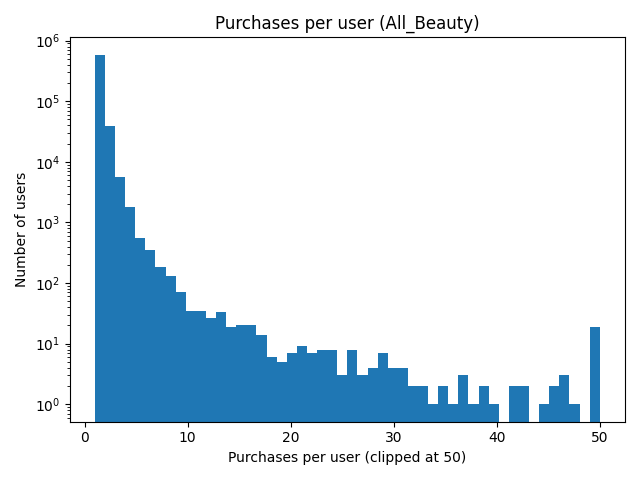

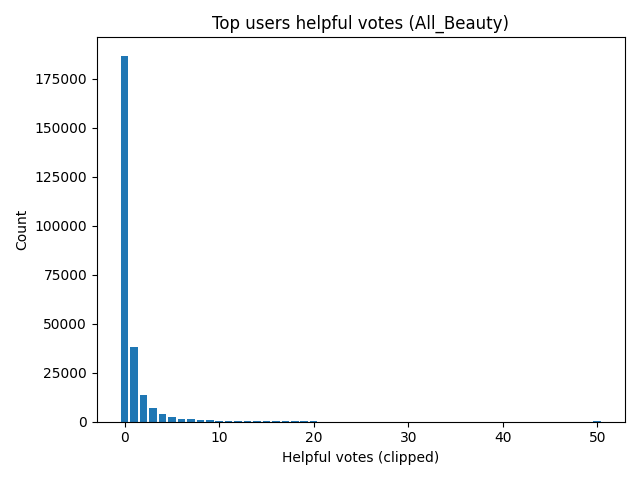

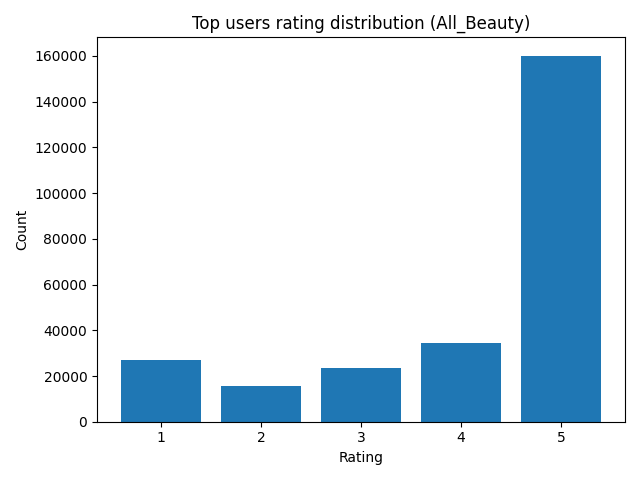

In [ ]:
def process_category(
    category,
    raw_dir,
    processed_dir,
    cleanup_raw,
    cleanup_processed,
    allow_download,
    repo_root,
):
    print(f"\n=== Category: {category} ===")

    # Lock (per-script, per-category, Drive-aware)
    lock_dir = repo_root / "data" / "locks" / "01_build_user_purchase_counts"
    lock_path = lock_dir / f"{category}.lock"

    # Try to hydrate remote lock from Drive
    rel_lock = str(lock_path.relative_to(repo_root))
    try:
        ensure_local_path(rel_lock)
    except Exception:
        pass

    lock_dir.mkdir(parents=True, exist_ok=True)

    if lock_path.exists():
        print(
            f"  [lock] Detected existing lock for {category} at {lock_path}. "
            "Skipping this category."
        )
        return

    with open(lock_path, "w", encoding="utf-8") as lf:
        lf.write("locked\n")
        
    upload_to_drive(lock_path)

    try:
        # Paths
        review_url = REVIEW_URL_TEMPLATE.format(category=category)
        meta_url = META_URL_TEMPLATE.format(category=category)

        review_gz_path = raw_dir / "reviews" / f"{category}.jsonl.gz"
        meta_gz_path = raw_dir / "meta" / f"meta_{category}.jsonl.gz"

        cat_proc_dir = processed_dir / category
        cat_proc_dir.mkdir(parents=True, exist_ok=True)

        user_counts_path = cat_proc_dir / f"user_counts_{category}.parquet"
        review_stats_path = cat_proc_dir / f"review_stats_{category}.json"
        rating_hist_png = cat_proc_dir / f"rating_hist_{category}.png"
        helpful_hist_png = cat_proc_dir / f"helpful_votes_hist_{category}.png"
        user_purchases_png = cat_proc_dir / f"user_purchases_hist_{category}.png"
        meta_stats_path = cat_proc_dir / f"meta_stats_{category}.json"

        expected_outputs = [
            user_counts_path,
            review_stats_path,
            rating_hist_png,
            helpful_hist_png,
            user_purchases_png,
            meta_stats_path,
        ]

        ensure_outputs_from_drive(expected_outputs, repo_root)

        # Category-level skip if everything is already there
        if all(p.exists() for p in expected_outputs):
            print("  [skip] all processed outputs exist for this category; skipping heavy work.")
            if cleanup_raw:
                for p in (review_gz_path, meta_gz_path):
                    if p.exists():
                        print(f"  [cleanup] removing {p}")
                        p.unlink()
            print(f"=== Done category (skipped): {category} ===")
            return

        # Always ensure gz files are present
        ensure_raw_gzip_or_download(
            review_gz_path, review_url, allow_download, repo_root
        )
        ensure_raw_gzip_or_download(
            meta_gz_path, meta_url, allow_download, repo_root
        )

        # Step 1: ensure review_stats + user_counts exist
        user_counts_df = None
        rating_hist = None
        helpful_hist = None

        if user_counts_path.exists() and review_stats_path.exists():
            print("  [skip] user_counts + review_stats already exist; loading from disk.")
            
            user_counts_df = pd.read_parquet(user_counts_path)
            
            with open(review_stats_path, "r", encoding="utf-8") as f:
                stats = json.load(f)
                
            rating_hist = Counter(
                {float(k): v for k, v in stats["rating_hist"].items()}
            )
            helpful_hist = Counter(
                {int(k): v for k, v in stats["helpful_hist"].items()}
            )
            
        else:
            print("  [run] computing review_stats + user_counts from gz.")
            
            try:
                review_stats_raw = process_review_file(
                    review_gz_path, category
                )
            except EOFError:
                print(
                    f"  [warn] Detected truncated gzip for {category}, re-downloading..."
                )
                download_if_needed(review_url, review_gz_path, force=True)
                review_stats_raw = process_review_file(
                    review_gz_path, category
                )

            user_counts = review_stats_raw["user_counts"]
            rating_hist = review_stats_raw["rating_hist"]
            helpful_hist = review_stats_raw["helpful_hist"]

            user_counts_rows = [
                {"user_id": uid, "num_purchases": cnt, "category": category}
                for uid, cnt in user_counts.items()
            ]
            user_counts_df = pd.DataFrame(user_counts_rows)
            user_counts_df.to_parquet(user_counts_path, index=False)
            
            print(f"[save] user_counts -> {user_counts_path}")

            review_stats_out = {
                "category": category,
                "n_reviews": review_stats_raw["n_reviews"],
                "n_users": len(user_counts),
                "n_verified": review_stats_raw["n_verified"],
                "rating_hist": dict(rating_hist),
                "helpful_hist": dict(helpful_hist),
            }
            with open(review_stats_path, "w", encoding="utf-8") as f:
                json.dump(review_stats_out, f, indent=2)
                
            print(f"[save] review_stats -> {review_stats_path}")

        # Step 2: ensure plots exist
        if not rating_hist_png.exists():
            save_rating_hist_plot(
                rating_hist,
                rating_hist_png,
                title=f"Rating distribution ({category})",
            )
        else:
            print(f"  [skip] rating hist plot already exists: {rating_hist_png}")

        if not helpful_hist_png.exists():
            save_helpful_hist_plot(
                helpful_hist,
                helpful_hist_png,
                title=f"Helpful votes distribution ({category})",
            )
        else:
            print(f"  [skip] helpful votes plot already exists: {helpful_hist_png}")

        if not user_purchases_png.exists():
            save_user_purchases_hist_plot(
                dict(zip(user_counts_df["user_id"], user_counts_df["num_purchases"])),
                user_purchases_png,
                title=f"Purchases per user ({category})",
            )
        else:
            print(f"  [skip] user purchases plot already exists: {user_purchases_png}")

        # Step 3: ensure meta_stats exist
        if meta_stats_path.exists():
            print(f"[skip] meta_stats already exist: {meta_stats_path}")
        else:
            print("[run] computing meta_stats from gz.")
            try:
                meta_stats_raw = process_meta_file(meta_gz_path)
            except EOFError:
                print(
                    f"[warn] Detected truncated meta gzip for {category}, re-downloading..."
                )
                download_if_needed(meta_url, meta_gz_path, force=True)
                meta_stats_raw = process_meta_file(meta_gz_path)

            meta_stats_out = {
                "category": category,
                "n_items": meta_stats_raw["n_items"],
                "rating_number_hist": dict(
                    meta_stats_raw["rating_number_hist"]
                ),
                "price_count": meta_stats_raw["price_count"],
                "price_mean": (
                    meta_stats_raw["price_sum"]
                    / meta_stats_raw["price_count"]
                    if meta_stats_raw["price_count"] > 0
                    else None
                ),
            }
            with open(meta_stats_path, "w", encoding="utf-8") as f:
                json.dump(meta_stats_out, f, indent=2)
                
            print(f"[save] meta_stats -> {meta_stats_path}")

        # Upload processed artifacts to Drive
        upload_targets = [
            user_counts_path,
            review_stats_path,
            rating_hist_png,
            helpful_hist_png,
            user_purchases_png,
            meta_stats_path,
        ]
        print("[drive] uploading processed outputs to Drive...")
        for p in upload_targets:
            try:
                upload_to_drive(p)
            except Exception as e:
                print(f"  [drive] WARNING: failed to upload {p}: {e}")

        if cleanup_processed != "none":
            for p in upload_targets:
                if cleanup_processed == "parquet" and p.suffix != ".parquet":
                    continue
                # 'all' -> delete everything in upload_targets
                if p.exists():
                    print(f"[cleanup-processed] removing {p}")
                    p.unlink()

        if cleanup_raw:
            for p in (review_gz_path, meta_gz_path):
                if p.exists():
                    print(f"  [cleanup-raw] removing {p}")
                    p.unlink()

        print(f"=== Done category: {category} ===")

    finally:
        # Always try to release lock
        if lock_path.exists():
            try:
                lock_path.unlink()
            except OSError:
                pass

"""
for cat in categories:
    try:
        process_category(
            cat,
            raw_dir=raw_dir,
            processed_dir=processed_dir,
            cleanup_raw=cleanup_raw,
            cleanup_processed=cleanup_processed,
            allow_download=allow_download,
            repo_root=repo_root,
        )
    except Exception as e:
        print(f"  [error] processing {cat}: {e}")
"""

## 2. Filter 'important' users

Global user collation,
Extract top users that satisfy:
* importance >= 95th percentile
* distinct_categories >= 3
* total_purchases >= 3

In [ ]:
BASE_DIR = Path("data/processed")
OUT_DIR = Path("data/global")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
def compute_entropy(counts):
    total = counts.sum()
    if total == 0:
        return 0.0
        
    p = counts / total
    p = p[p > 0]  # avoid log(0)
    return -(p * np.log(p)).sum()

def load_all_user_counts():
    files = list(BASE_DIR.glob("*/user_counts_*.parquet"))

    dfs = []
    for f in tqdm(files, desc="Loading user_counts"):
        dfs.append(pd.read_parquet(f))

    return pd.concat(dfs, ignore_index=True)

def aggregate_user_data(df):
    pivot = df.pivot_table(
        index="user_id",
        columns="category",
        values="num_purchases",
        aggfunc="sum",
        fill_value=0
    )

    pivot["total_purchases"] = pivot.sum(axis=1)
    pivot["distinct_categories"] = (pivot.drop(columns="total_purchases") > 0).sum(axis=1)
    return pivot

In [ ]:
def compute_user_importance(df:pd.DataFrame):
    category_cols = [c for c in df.columns if c not in ["total_purchases", "distinct_categories"]]

    df["entropy"] = df[category_cols].apply(lambda row: compute_entropy(row.values), axis=1)

    max_entropy = np.log(len(category_cols))
    df["norm_entropy"] = df["entropy"] / max_entropy

    df["importance"] = df["total_purchases"] * (1 + df["norm_entropy"])

    return df

def extract_top_users(df:pd.DataFrame, percentile=0.95):
    importance_threshold = df["importance"].quantile(percentile)

    filtered = df[
        (df["importance"] >= importance_threshold) &
        (df["total_purchases"] >= 3) &
        (df["distinct_categories"] >= 3)
    ]

    return filtered

In [ ]:
def save_histograms(df:pd.DataFrame):
    # Total purchases hist
    plt.figure(figsize=(8, 5))
    df["total_purchases"].clip(upper=50).hist(bins=50)
    plt.title("User Total Purchase Counts (clipped at 50)")
    plt.xlabel("Total Purchases")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "user_total_purchases_hist.png")
    plt.close()

    # Distinct categories hist
    plt.figure(figsize=(8, 5))
    df["distinct_categories"].hist(bins=50)
    plt.title("Distinct Categories per User")
    plt.xlabel("Num Categories")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "user_distinct_categories_hist.png")
    plt.close()

In [ ]:
raw = load_all_user_counts()
user_df = aggregate_user_data(raw)
save_histograms(user_df)
user_df = compute_user_importance(user_df)
top_users = extract_top_users(user_df, percentile=0.95)

top_out = OUT_DIR / "top_users.parquet"
top_users.to_parquet(top_out)
print(f"Saved top users → {top_out}")

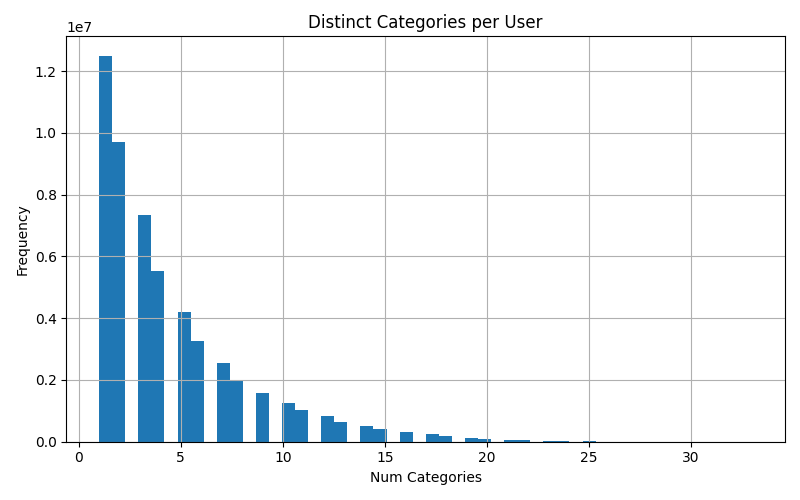

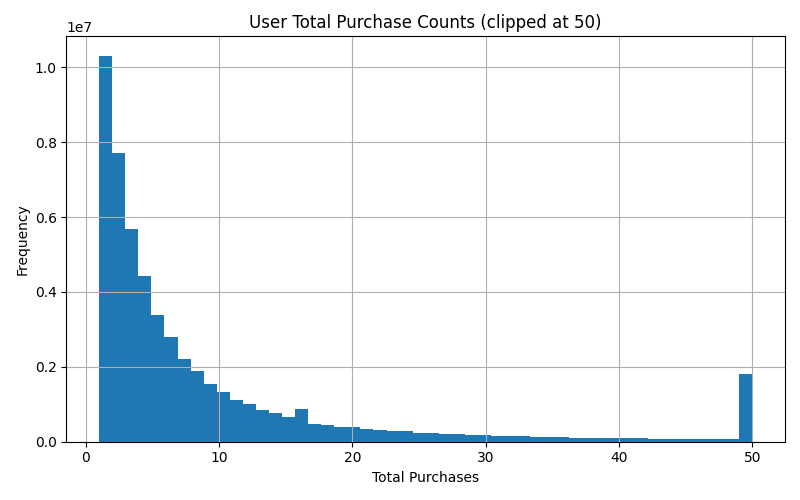

## 3. Extract per-review, per-user, and per-item features for top users (per-category).

For each category:
  - Load global top_users (importance scores) from data/global/top_users.parquet.
  - Stream the category review .jsonl.gz and keep only reviews by top users.
  - Produce per-review feature table:
      data/processed/<Category>/top_user_reviews_<Category>.parquet
  - Produce per-user aggregated features:
      data/processed/<Category>/top_user_features_<Category>.parquet
  - Produce per-item aggregated features (from top users only):
      data/processed/<Category>/top_item_features_<Category>.parquet
  - Produce EDA outputs:
      top_user_review_stats_<Category>.json
      top_users_rating_hist_<Category>.png
      top_users_helpful_hist_<Category>.png

In [ ]:
def parse_reviews_for_top_users(
    review_gz,
    top_users_set,
    item_meta,
    category,
    progress_intervat,
    total_lines,
    out_reviews_parquet,
    parquet_batch_size = 500_000,
):
    if out_reviews_parquet.exists():
        out_reviews_parquet.unlink()

    rating_hist = Counter()
    helpful_hist = Counter()
    seen_users = set()

    n_lines = 0
    n_kept = 0
    start_time = time.time()

    rows_batch: List[Dict] = []
    writer = None

    def flush_batch():
        nonlocal writer, rows_batch
        if not rows_batch:
            return
            
        # Convert list-of-dicts to column-wise dict for pyarrow
        keys = rows_batch[0].keys()
        cols = {k: [row[k] for row in rows_batch] for k in keys}
        table = pa.Table.from_pydict(cols)
        
        if writer is None:
            writer = pq.ParquetWriter(str(out_reviews_parquet), table.schema)
            
        writer.write_table(table)
        rows_batch = []

    with gzip.open(review_gz, "rt", encoding="utf-8") as f:
        for line in f:
            n_lines += 1
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue

            user_id = obj.get("user_id")
            if user_id is None:
                continue
            user_id = str(user_id)
            if user_id not in top_users_set:
                continue

            product_id = (
                obj.get("asin")
                or obj.get("product_id")
                or obj.get("item_id")
                or obj.get("id")
            )
            rating = obj.get("rating")

            hv = obj.get("helpful_votes", obj.get("helpful_vote", 0))
            try:
                hv = int(hv)
            except (TypeError, ValueError):
                hv = 0
            hv_clipped = min(hv, 50)

            unix_time = (
                obj.get("timestamp")
                or obj.get("unixReviewTime")
                or obj.get("unix_review_time")
                or obj.get("unix_time")
            )

            verified = (
                obj.get("verified_purchase") or obj.get("verified") or False
            )

            im = (
                item_meta.get(str(product_id), {})
                if product_id is not None
                else {}
            )

            row = {
                "user_id": user_id,
                "product_id": product_id,
                "unixReviewTime": int(unix_time) if unix_time is not None else None,
                "rating": float(rating) if rating is not None else None,
                "helpful_votes": hv,
                "helpful_votes_clipped": hv_clipped,
                "verified_purchase": bool(verified),
                "item_avg_rating": im.get("item_avg_rating"),
                "item_categories": im.get("item_categories"),
            }

            rows_batch.append(row)
            seen_users.add(user_id)
            n_kept += 1

            # Flush Parquet batch
            if len(rows_batch) >= parquet_batch_size:
                flush_batch()

            # Progress / ETA logging
            if progress_interval > 0 and n_lines % progress_interval == 0:
                elapsed = time.time() - start_time
                rate = n_lines / elapsed if elapsed > 0 else 0.0

                if total_lines:
                    frac = min(n_lines / total_lines, 1.0)
                    pct = frac * 100.0
                    eta_str = "unknown"
                    if rate > 0:
                        remaining = max(total_lines - n_lines, 0)
                        eta_sec = remaining / rate
                        mins = int(eta_sec // 60)
                        secs = int(eta_sec % 60)
                        eta_str = f"{mins}m {secs}s"
                    print(
                        f"[parse] {category}: "
                        f"{n_lines:,}/{total_lines:,} lines "
                        f"({pct:5.1f}%), kept={n_kept:,}, "
                        f"users_with_reviews={len(seen_users):,}, "
                        f"rate={rate:,.0f} lines/s, ETA={eta_str}"
                    )
                else:
                    print(
                        f"[parse] {category}: "
                        f"lines_seen={n_lines:,}, kept={n_kept:,}, "
                        f"users_with_reviews={len(seen_users):,}"
                    )

            # Histograms
            try:
                if rating is not None:
                    rating_hist[float(rating)] += 1
            except (TypeError, ValueError):
                pass
            helpful_hist[hv_clipped] += 1

    # Flush any remaining rows
    flush_batch()
    if writer is not None:
        writer.close()
    else:
        # No rows kept at all → create an empty parquet with expected columns
        empty_df = pd.DataFrame(
            columns=[
                "user_id",
                "product_id",
                "unixReviewTime",
                "rating",
                "helpful_votes",
                "helpful_votes_clipped",
                "verified_purchase",
                "item_avg_rating",
                "item_categories",
            ]
        )
        empty_df.to_parquet(out_reviews_parquet, index=False)

    if total_lines:
        print(
            f"  [done] filtered reviews rows={n_kept:,}, "
            f"users_with_reviews={len(seen_users):,}, "
            f"lines_seen={n_lines:,}/{total_lines:,}"
        )
    else:
        print(
            f"  [done] filtered reviews rows={n_kept:,}, "
            f"users_with_reviews={len(seen_users):,}, "
            f"lines_seen={n_lines:,}"
        )

    return rating_hist, helpful_hist, len(seen_users), n_kept

In [ ]:
def process_category(
    category,
    raw_dir,
    processed_dir,
    top_users_df,
    top_users_set,
    allow_download,
    cleanup_raw,
    cleanup_processed,
    repo_root,
    progress_interval,
):
    # Paths
    review_gz = raw_dir / "reviews" / f"{category}.jsonl.gz"
    meta_gz = raw_dir / "meta" / f"meta_{category}.jsonl.gz"
    review_url = REVIEW_URL_TEMPLATE.format(category=category)
    meta_url = META_URL_TEMPLATE.format(category=category)

    cat_proc_dir = processed_dir / category
    cat_proc_dir.mkdir(parents=True, exist_ok=True)

    out_reviews_parquet = cat_proc_dir / f"top_user_reviews_{category}.parquet"
    out_user_features = cat_proc_dir / f"top_user_features_{category}.parquet"
    out_item_features = cat_proc_dir / f"top_item_features_{category}.parquet"
    out_stats_json = cat_proc_dir / f"top_user_review_stats_{category}.json"
    rating_png = cat_proc_dir / f"top_users_rating_hist_{category}.png"
    helpful_png = cat_proc_dir / f"top_users_helpful_hist_{category}.png"

    expected_outputs = [
        out_reviews_parquet,
        out_user_features,
        out_item_features,
        out_stats_json,
        rating_png,
        helpful_png,
    ]

    lock_dir = repo_root / "data" / "locks" / "03_user_features"
    lock_dir.mkdir(parents=True, exist_ok=True)
    lock_path = lock_dir / f"{category}.lock"
    rel_lock = str(lock_path.relative_to(repo_root))

    try:
        if remote_file_exists_by_rel_path(rel_lock) and not lock_path.exists():
            ensure_local_path(rel_lock)
    except Exception:
        pass

    if lock_path.exists():
        ensure_outputs_from_drive(expected_outputs, repo_root)

        if all(p.exists() for p in expected_outputs):
            try:
                lock_path.unlink()
            except OSError:
                pass
            delete_remote_by_rel_path(rel_lock)
        else:
            # Stale lock: outputs missing, so we take over
            try:
                lock_path.unlink()
            except OSError:
                pass
            try:
                delete_remote_by_rel_path(rel_lock)
            except Exception as e:
                print(f"  [lock] WARNING: failed to delete remote lock: {e}")

    # If we get here, either there was no lock or we just cleared a stale one.
    with open(lock_path, "w", encoding="utf-8") as lf:
        lf.write("locked\n")
    try:
        upload_to_drive(lock_path)
    except Exception as e:
        print(f"  [lock] WARNING: failed to upload lock to Drive: {e}")

    try:
        review_gz = raw_dir / "reviews" / f"{category}.jsonl.gz"
        meta_gz = raw_dir / "meta" / f"meta_{category}.jsonl.gz"
        review_url = REVIEW_URL_TEMPLATE.format(category=category)
        meta_url = META_URL_TEMPLATE.format(category=category)

        cat_proc_dir = processed_dir / category
        cat_proc_dir.mkdir(parents=True, exist_ok=True)

        # Outputs
        out_reviews_parquet = cat_proc_dir / f"top_user_reviews_{category}.parquet"
        out_user_features = cat_proc_dir / f"top_user_features_{category}.parquet"
        out_item_features = cat_proc_dir / f"top_item_features_{category}.parquet"
        out_stats_json = cat_proc_dir / f"top_user_review_stats_{category}.json"
        rating_png = cat_proc_dir / f"top_users_rating_hist_{category}.png"
        helpful_png = cat_proc_dir / f"top_users_helpful_hist_{category}.png"

        expected_outputs = [
            out_reviews_parquet,
            out_user_features,
            out_item_features,
            out_stats_json,
            rating_png,
            helpful_png,
        ]

        # Try to pull processed outputs from Drive if they exist there
        ensure_outputs_from_drive(expected_outputs, repo_root)

        # Category-level skip if EVERYTHING exists
        if all(p.exists() for p in expected_outputs):
            print("  [skip] all processed outputs exist for this category")
            # Optional cleanup of raw gz if requested
            if cleanup_raw:
                for p in (review_gz, meta_gz):
                    if p.exists():
                        print(f"  [cleanup-raw] removing {p}")
                        p.unlink()
            print(f"=== Done category (skipped): {category} ===")
            return

        # Which steps we actually need
        need_step1 = not (
            out_reviews_parquet.exists() and out_stats_json.exists()
        )
        need_step2 = not out_user_features.exists()
        need_step3 = not out_item_features.exists()
        need_step4 = not (rating_png.exists() and helpful_png.exists())

        total_lines: Optional[int] = None

        # We need the review gzip if we are going to reparse
        if need_step1:
            ensure_raw_gzip_or_download(
                review_gz, review_url, allow_download, repo_root
            )
            total_lines = count_gzip_lines(review_gz, category)

        # We need meta if we are going to parse or create item-level aggregates
        need_meta = need_step1 or need_step3
        item_meta: Dict[str, Dict] = {}

        if need_meta:
            ensure_raw_gzip_or_download(
                meta_gz, meta_url, allow_download, repo_root
            )
            if meta_gz.exists():
                try:
                    item_meta = load_item_meta(meta_gz, category)
                except EOFError:
                    print(
                        f"  [warn] truncated meta gzip for {category}; "
                        "re-downloading and retrying..."
                    )
                    download_if_needed(meta_url, meta_gz, force=True)
                    item_meta = load_item_meta(meta_gz, category)

        print(
            f"  [info] top_users provided: {len(top_users_set)} users; filtering reviews..."
        )

        # Step 1: filtered reviews + stats (streaming parser)
        if not need_step1:
            print("  [skip] filtered reviews + stats already exist; loading from disk.")
            with open(out_stats_json, "r", encoding="utf-8") as f:
                stats = json.load(f)
            rating_hist = Counter(
                {float(k): v for k, v in stats.get("rating_hist", {}).items()}
            )
            helpful_hist = Counter(
                {int(k): v for k, v in stats.get("helpful_hist", {}).items()}
            )
            n_reviews = int(stats.get("n_reviews", 0))
            n_users = int(stats.get("n_users", 0))
        else:
            try:
                rating_hist, helpful_hist, n_users, n_reviews = (
                    parse_reviews_for_top_users(
                        review_gz,
                        top_users_set,
                        item_meta,
                        category,
                        progress_interval,
                        total_lines,
                        out_reviews_parquet,
                    )
                )
            except EOFError:
                download_if_needed(review_url, review_gz, force=True)
                rating_hist, helpful_hist, n_users, n_reviews = (
                    parse_reviews_for_top_users(
                        review_gz,
                        top_users_set,
                        item_meta,
                        category,
                        progress_interval,
                        total_lines,
                        out_reviews_parquet,
                    )
                )

            stats_out = {
                "category": category,
                "n_reviews": int(n_reviews),
                "n_users": int(n_users),
                "rating_hist": dict(rating_hist),
                "helpful_hist": dict(helpful_hist),
            }
            with open(out_stats_json, "w", encoding="utf-8") as f:
                json.dump(stats_out, f, indent=2)
            print(f"  [save] stats -> {out_stats_json}")

        if n_reviews == 0:
            print("  [warn] No reviews for top users in this category.")
            if not out_user_features.exists():
                pd.DataFrame(columns=["user_id"]).to_parquet(
                    out_user_features, index=False
                )
                print(
                    f"  [save] empty per-user features -> {out_user_features}"
                )
            if not out_item_features.exists():
                pd.DataFrame(columns=["product_id"]).to_parquet(
                    out_item_features, index=False
                )
                print(
                    f"  [save] empty per-item features -> {out_item_features}"
                )
            if need_step4:
                save_rating_hist_plot(
                    rating_hist,
                    rating_png,
                    title=f"Top users rating distribution ({category})",
                )
                save_helpful_hist_plot(
                    helpful_hist,
                    helpful_png,
                    title=f"Top users helpful votes ({category})",
                )

        reviews_df: Optional[pd.DataFrame] = None
        if (need_step2 or need_step3) and n_reviews > 0:
            print("  [load] reading top-user reviews parquet for aggregation...")
            reviews_df = pd.read_parquet(out_reviews_parquet)

        # Step 2: per-user aggregated features
        if not need_step2:
            print(
                f"  [skip] per-user features already exist: {out_user_features}"
            )
        else:
            print("  [run] computing per-user aggregated features...")
            agg = (
                reviews_df.groupby("user_id")
                .agg(
                    num_purchases_in_category=("product_id", "count"),
                    avg_rating_in_category=("rating", "mean"),
                    avg_helpful_vote_in_category=("helpful_votes", "mean"),
                    avg_item_avg_rating=("item_avg_rating", "mean"),
                    first_review_time=("unixReviewTime", "min"),
                    last_review_time=("unixReviewTime", "max"),
                )
                .reset_index()
            )

            top_users_df_local = top_users_df.copy()
            if "user_id" not in top_users_df_local.columns:
                top_users_df_local = top_users_df_local.reset_index()

            top_users_df_local["user_id"] = top_users_df_local[
                "user_id"
            ].astype(str)
            agg["user_id"] = agg["user_id"].astype(str)

            sel = agg.merge(top_users_df_local, on="user_id", how="left")

            sel.to_parquet(out_user_features, index=False)
            print(f"  [save] per-user features -> {out_user_features}")

        # Step 3: per-item aggregated features
        if not need_step3:
            print(
                f" [skip] per-item features already exist: {out_item_features}"
            )
        else:
            print(" [run] computing per-item aggregated features...")
            item_agg = (
                reviews_df.groupby("product_id")
                .agg(
                    num_topuser_reviews=("user_id", "count"),
                    num_unique_topusers=("user_id", "nunique"),
                    avg_rating_topusers=("rating", "mean"),
                    avg_helpful_votes_topusers=("helpful_votes", "mean"),
                    first_review_time=("unixReviewTime", "min"),
                    last_review_time=("unixReviewTime", "max"),
                )
                .reset_index()
            )

            def _get_meta_avg(asin):
                return item_meta.get(str(asin), {}).get("item_avg_rating")

            def _get_meta_cats(asin):
                return item_meta.get(str(asin), {}).get("item_categories")

            item_agg["item_avg_rating_meta"] = item_agg["product_id"].map(
                _get_meta_avg
            )
            item_agg["item_categories_meta"] = item_agg["product_id"].map(
                _get_meta_cats
            )

            item_agg.to_parquet(out_item_features, index=False)
            print(f" [save] per-item features -> {out_item_features}")

        if not rating_png.exists():
            save_rating_hist_plot(
                rating_hist,
                rating_png,
                title=f"Top users rating distribution ({category})",
            )
        else:
            print(f"[skip] rating hist plot already exists: {rating_png}")

        if not helpful_png.exists():
            save_helpful_hist_plot(
                helpful_hist,
                helpful_png,
                title=f"Top users helpful votes ({category})",
            )
        else:
            print(f"[skip] helpful votes plot already exists: {helpful_png}")

        # Upload processed artifacts to Drive
        upload_targets = [
            out_reviews_parquet,
            out_user_features,
            out_item_features,
            out_stats_json,
            rating_png,
            helpful_png,
        ]
        for p in upload_targets:
            try:
                upload_to_drive(p)
            except Exception as e:
                print(f"  [drive] WARNING: failed to upload {p}: {e}")

        # Cleanup processed outputs (optional)
        if cleanup_processed != "none":
            for p in upload_targets:
                if cleanup_processed == "parquet" and p.suffix != ".parquet":
                    continue
                try:
                    if p.exists():
                        p.unlink()
                except OSError as e:
                    print(f" [cleanup-processed] WARNING: failed to remove {p}: {e}")

        # Cleanup raw gz if requested
        if cleanup_raw:
            for p in (review_gz, meta_gz):
                if p.exists():
                    print(f" [cleanup-raw] removing {p}")
                    p.unlink()

    finally:
        # Always try to release lock
        if lock_path.exists():
            try:
                lock_path.unlink()
            except OSError:
                pass

        try:
            rel_lock = str(lock_path.relative_to(repo_root))
            delete_remote_by_rel_path(rel_lock)
        except Exception:
            pass

In [ ]:
top_users_df = load_top_users(top_users_path)
# Fast membership checks
top_users_set = set(top_users_df["user_id"].astype(str).tolist())

total_categories = len(categories)
for idx, cat in enumerate(categories, start=1):
    print(f"\n[{idx}/{total_categories}] Starting category: {cat}")
    try:
        process_category(
            cat,
            raw_dir=raw_dir,
            processed_dir=processed_dir,
            top_users_df=top_users_df,
            top_users_set=top_users_set,
            allow_download=allow_download,
            cleanup_raw=cleanup_raw,
            cleanup_processed=cleanup_processed,
            repo_root=repo_root,
            progress_interval=progress_interval,
        )
    except Exception as e:
        print(f"  [error] processing {cat}: {e}")

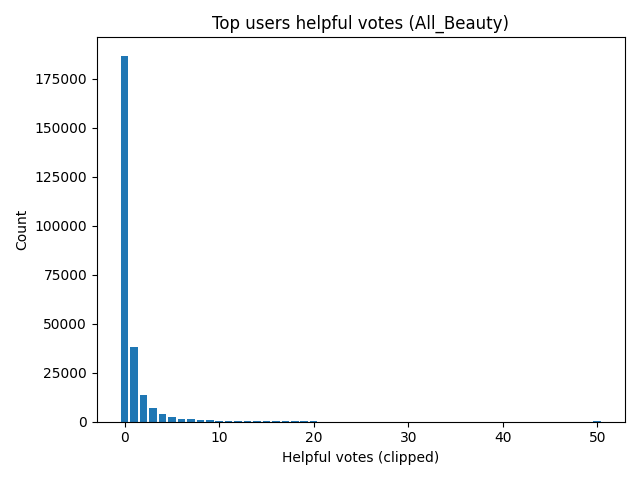

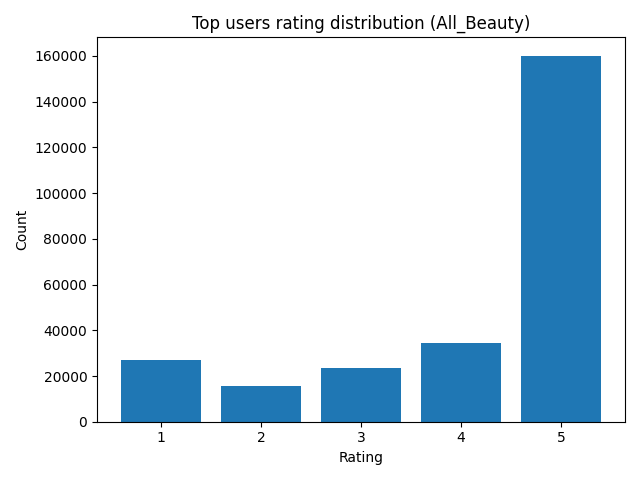

# Feature Engineering

## Build Training Dataset

For each user, we sort reviews by time and create prefixes of their history.

For each prefix, we build features using only past information:

* Static user stats (importance, entropy, total purchases, etc.).
* Prefix-level summaries (length, timespan, mean ratings, helpfulness, item average rating).
* Sequential context: last category, last k categories as indices.
* Prefix category counts (prefix_cat_count_*) and the most frequent prefix category.

The label is the category of the next purchase.

To keep everything scalable and user-level consistent, we:

* Shard by user (hash(user_id)) and store per-shard Parquet files.
* Perform an 80/10/10 split by shards → train/validation/test splits are user-disjoint.
* Cap rows per split to respect memory constraints while still using hundreds of thousands of samples

In [ ]:
# Phase 0: shard user features by user_id

def shard_user_features(
    categories,
    tmp_user_dir,
    n_shards = 256,
):

    os.makedirs(tmp_user_dir, exist_ok=True)

    for cat in categories:
        path = f"data/processed/{cat}/top_user_features_{cat}.parquet"
        if not os.path.exists(path):
            print(f"[warn] missing user features parquet for {cat}: {path}")
            continue

        print(f"[user-shard] loading user features for {cat} from {path}")
        df = pd.read_parquet(path)

        if "user_id" not in df.columns:
            print(f"[warn] {cat} user features missing user_id; skipping")
            continue

        df["user_id"] = df["user_id"].astype(str)

        shard_ids = hash_pandas_object(df["user_id"], index=False).values % n_shards
        df["user_shard"] = shard_ids.astype("int32")

        print(f"[user-shard] writing {len(df):,} rows for {cat} into user shards...")
        table = pa.Table.from_pandas(df)

        pq.write_to_dataset(
            table,
            root_path=tmp_user_dir,
            partition_cols=["user_shard"],
        )

        del df, table
        gc.collect()

# Phase 1: shard reviews by user_id

def shard_reviews_by_user(
    categories,
    category_index,
    tmp_dir,
    n_shards=256,
):

    os.makedirs(tmp_dir, exist_ok=True)

    for cat in categories:
        path = f"data/processed/{cat}/top_user_reviews_{cat}.parquet"
        if not os.path.exists(path):
            print(f"[warn] missing reviews parquet for {cat}: {path}")
            continue

        df = pd.read_parquet(path)

        df["user_id"] = df["user_id"].astype(str)
        df = df.dropna(subset=["unixReviewTime"])
        df["unixReviewTime"] = df["unixReviewTime"].astype("int64")

        if "rating" not in df.columns:
            df["rating"] = np.nan
        if "helpful_votes" not in df.columns:
            df["helpful_votes"] = 0
        if "item_avg_rating" not in df.columns:
            df["item_avg_rating"] = np.nan
        if "verified_purchase" not in df.columns:
            df["verified_purchase"] = False

        df["category"] = cat
        df["category_idx"] = df["category"].map(
            lambda c: category_index.get(c, 0)
        )

        shard_ids = hash_pandas_object(df["user_id"], index=False).values % n_shards
        df["user_shard"] = shard_ids.astype("int32")

        print(f"[review-shard] writing {len(df):,} rows for {cat} into review shards...")
        table = pa.Table.from_pandas(df)

        pq.write_to_dataset(
            table,
            root_path=tmp_dir,
            partition_cols=["user_shard"],
        )

        del df, table
        gc.collect()

In [ ]:
def build_sequence_dataset_for_shard(
    reviews_df,
    user_features_df,
    category_index,
    n_latest = 5,
    min_prefix = 3,
    disable_prefix_cat_counts= False,
    sample_every_k_prefix = 1,
):
    if reviews_df.empty:
        return pd.DataFrame()

    reviews_df = reviews_df.copy()

    reviews_df["user_id"] = reviews_df["user_id"].astype(str)

    required_cols = ["user_id", "unixReviewTime", "category_idx"]
    for col in required_cols:
        if col not in reviews_df.columns:
            raise ValueError(f"shard reviews_df missing required column '{col}'")

    reviews_df = reviews_df.dropna(subset=["unixReviewTime"])
    reviews_df["unixReviewTime"] = reviews_df["unixReviewTime"].astype("int64")

    if "rating" not in reviews_df.columns:
        reviews_df["rating"] = np.nan
    if "helpful_votes" not in reviews_df.columns:
        reviews_df["helpful_votes"] = 0
    if "item_avg_rating" not in reviews_df.columns:
        reviews_df["item_avg_rating"] = np.nan
    if "verified_purchase" not in reviews_df.columns:
        reviews_df["verified_purchase"] = False
    if "category" not in reviews_df.columns:
        # Map category_idx back to name
        idx_to_cat = {idx: name for name, idx in category_index.items()}
        reviews_df["category"] = reviews_df["category_idx"].map(
            lambda i: idx_to_cat.get(i, "Unknown")
        )

    # Static user features (per shard)
    uf = user_features_df.copy()
    if not uf.empty:
        uf["user_id"] = uf["user_id"].astype(str)
        uf = uf.drop_duplicates(subset=["user_id"], keep="first")
        uf = uf.set_index("user_id", drop=False)
        static_feature_cols = [c for c in uf.columns if c != "user_id"]
    else:
        uf = pd.DataFrame(columns=["user_id"]).set_index("user_id", drop=False)
        static_feature_cols = []

    # Group by user within this shard
    grouped = reviews_df.groupby("user_id", sort=False)

    num_cats = max(category_index.values()) if category_index else 0
    samples = []

    np_isnan = np.isnan
    pd_isna = pd.isna
    category_items = list(category_index.items())

    for user_id, user_group in grouped:
        user_group = user_group.sort_values("unixReviewTime")
        n = len(user_group)
        if n <= min_prefix:
            continue

        times = user_group["unixReviewTime"].to_numpy()
        cat_idxs = user_group["category_idx"].to_numpy()
        ratings = user_group["rating"].to_numpy()
        helpful = user_group["helpful_votes"].to_numpy()
        item_avg = user_group["item_avg_rating"].to_numpy()
        verified = user_group["verified_purchase"].to_numpy()
        target_cats = user_group["category"].astype(str).to_numpy()

        if n == 0:
            continue

        # Prefix accumulators
        prefix_len = 0
        sum_rating = 0.0
        rating_count = 0
        sum_helpful = 0.0
        sum_item_avg = 0.0
        item_avg_count = 0
        cat_counts = np.zeros(num_cats + 1, dtype=np.int64)
        first_time = None

        # Static user features
        if user_id in uf.index:
            urow = uf.loc[user_id]
        else:
            urow = None

        for i in range(n):
            t = int(times[i])
            cidx = int(cat_idxs[i])
            r = ratings[i]
            h = helpful[i]
            ia = item_avg[i]
            v = bool(verified[i])

            prefix_len += 1
            if first_time is None:
                first_time = t
            cat_counts[cidx] += 1

            if not pd_isna(r):
                sum_rating += float(r)
                rating_count += 1
            if not pd_isna(h):
                sum_helpful += float(h)
            if not pd_isna(ia):
                sum_item_avg += float(ia)
                item_avg_count += 1

            if prefix_len < min_prefix or i >= n - 1:
                continue

            # Only keep every k-th prefix if k > 1
            if sample_every_k_prefix > 1:
                if (prefix_len - min_prefix) % sample_every_k_prefix != 0:
                    continue

            feat = {}

            # 1) ID
            feat["user_id"] = user_id

            # 2) Static user features
            if urow is not None:
                for col in static_feature_cols:
                    feat[col] = urow.get(col, np.nan)
            else:
                for col in static_feature_cols:
                    feat[col] = np.nan

            # 3) Prefix-level summary
            feat["prefix_length"] = prefix_len
            feat["prefix_timespan"] = (
                t - first_time if first_time is not None else 0
            )
            feat["prefix_avg_rating"] = (
                sum_rating / rating_count if rating_count > 0 else np.nan
            )
            feat["prefix_avg_helpful"] = (
                sum_helpful / prefix_len if prefix_len > 0 else 0.0
            )
            feat["prefix_avg_item_avg_rating"] = (
                sum_item_avg / item_avg_count if item_avg_count > 0 else np.nan
            )

            # 4) Last purchase features at time i
            feat["last_category_idx"] = cidx
            feat["last_rating"] = float(r) if not pd_isna(r) else np.nan
            feat["last_helpful_votes"] = float(h) if not pd_isna(h) else 0.0
            feat["last_item_avg_rating"] = (
                float(ia) if not pd_isna(ia) else np.nan
            )
            feat["last_verified"] = int(v)

            # 5) Last n_latest categories
            for k in range(n_latest):
                j = i - k
                if j >= 0:
                    feat[f"last_{k+1}_category_idx"] = int(cat_idxs[j])
                else:
                    feat[f"last_{k+1}_category_idx"] = 0

            # 6) Prefix category counts
            if not disable_prefix_cat_counts:
                for cat_name, idx in category_items:
                    if cat_name == "Unknown":
                        feat["prefix_cat_count_Unknown"] = int(cat_counts[idx])
                    else:
                        feat[f"prefix_cat_count_{cat_name}"] = int(cat_counts[idx])

            # 7) Most frequent category in prefix
            feat["prefix_most_freq_category_idx"] = int(cat_counts.argmax())

            # 8) Target: category at i+1
            next_idx = int(cat_idxs[i + 1])
            next_cat_name = target_cats[i + 1]

            feat["target_category_idx"] = next_idx
            feat["target_category"] = next_cat_name

            samples.append(feat)

    if not samples:
        return pd.DataFrame()

    return pd.DataFrame(samples)

In [ ]:
shard_user_features(
    categories=categories_ok,
    tmp_user_dir=args.tmp_user_dir,
    n_shards=args.n_shards,
)

shard_reviews_by_user(
    categories=categories_ok,
    category_index=category_index,
    tmp_dir=args.tmp_dir,
    n_shards=args.n_shards,
)

shard_dirs = list_shard_dirs(args.tmp_dir)
num_shards = len(shard_dirs)
print(f"[info] found {num_shards} review shard partitions in {args.tmp_dir}")

if not shard_dirs:
    raise RuntimeError("No shard directories found; sharding may have failed.")


os.makedirs(args.per_shard_output_dir, exist_ok=True)

shard_idx = 0
for shard_dir in tqdm(shard_dirs, desc="Shards"):
    shard_idx += 1
    shard_name = os.path.basename(shard_dir)  # e.g., "user_shard=123"
    print(f"\n[phase2] Shard {shard_idx}/{num_shards}: {shard_name} ")

    shard_output_path = os.path.join(
        args.per_shard_output_dir,
        f"sequence_{shard_name}.parquet",
    )

    if os.path.exists(shard_output_path) and args.resume_phase2:
        print(f"[phase2] shard {shard_name}: found existing {shard_output_path}, inspecting schema...")

        # Cheaply inspect schema without loading full data
        pf = pq.ParquetFile(shard_output_path)
        col_names = pf.schema.names
        has_prefix_counts = any(
            name.startswith("prefix_cat_count_") for name in col_names
        )

    # Load review shard
    rfiles = [
        os.path.join(shard_dir, f)
        for f in os.listdir(shard_dir)
        if f.endswith(".parquet")
    ]

    print(f"[phase2] shard {shard_name}: loading {len(rfiles)} review files...")
    shard_dfs = [pd.read_parquet(p) for p in rfiles]
    shard_reviews = pd.concat(shard_dfs, ignore_index=True)
    
    del shard_dfs
    gc.collect()

    num_rows = len(shard_reviews)
    num_users = shard_reviews["user_id"].nunique() if "user_id" in shard_reviews.columns else 0
    print(f"[phase2] shard {shard_name}: {num_rows:,} rows, {num_users:,} users")

    # Load matching user-feature shard
    user_shard_dir = os.path.join(args.tmp_user_dir, shard_name)
    if os.path.exists(user_shard_dir):
        ufiles = [
            os.path.join(user_shard_dir, f)
            for f in os.listdir(user_shard_dir)
            if f.endswith(".parquet")
        ]
        if ufiles:
            print(f"[phase2] shard {shard_name}: loading {len(ufiles)} user-feature files...")
            udfs = [pd.read_parquet(p) for p in ufiles]
            shard_user_features_df = pd.concat(udfs, ignore_index=True)
            
            del udfs
            gc.collect()
        else:
            print(f"[phase2] shard {shard_name}: no user-feature files (using empty).")
            shard_user_features_df = pd.DataFrame(columns=["user_id"])
    else:
        print(f"[phase2] shard {shard_name}: user-feature shard dir not found (using empty).")
        shard_user_features_df = pd.DataFrame(columns=["user_id"])

    seq_df_shard = build_sequence_dataset_for_shard(
        reviews_df=shard_reviews,
        user_features_df=shard_user_features_df,
        category_index=category_index,
        n_latest=args.n_latest,
        min_prefix=args.min_prefix,
        disable_prefix_cat_counts=args.disable_prefix_cat_counts,
        sample_every_k_prefix=args.sample_every_k_prefix,
    )
    
    del shard_reviews, shard_user_features_df
    gc.collect()

    shard_samples = len(seq_df_shard)
    print(f"[phase2] shard {shard_name}: created {shard_samples:,} sequence samples")

    # Write / overwrite per-shard output
    table = pa.Table.from_pandas(seq_df_shard)
    pq.write_table(table, shard_output_path)

    del seq_df_shard, table
    gc.collect()

# Modeling

Task: temporal next-category prediction: given a user’s purchase/review history up to time t, we want to predict the top-level category of their next purchase at time t+1.

We use a chunking approach where the training dataset is split up into data 'shards' to satisfy memory constraints

In [9]:
def evaluate_model(name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    print(f"MODEL: {name}")

    # Fit
    model.fit(X_train, y_train)

    metrics = {}

    def _eval_split(split_name, X, y_true):
        print(f"[{name}:{split_name}] Evaluating on {split_name} (n={len(y_true):,}) ...")
        y_pred = model.predict(X)
        acc = accuracy_score(y_true, y_pred)
        print(f"[{name}:{split_name}] Accuracy = {acc:.4f}")

        # Top-3 accuracy if possible
        top3 = None
        scores = None
        if hasattr(model, "predict_proba"):
            try:
                scores = model.predict_proba(X)
            except Exception as e:
                print(f"[{name}:{split_name}] predict_proba failed for top-k: {e}")
        elif hasattr(model, "decision_function"):
            try:
                scores = model.decision_function(X)
            except Exception as e:
                print(f"[{name}:{split_name}] decision_function failed for top-k: {e}")

        if scores is not None:
            try:
                top3 = top_k_accuracy_score(y_true, scores, k=3)
                print(f"[{name}:{split_name}] Top-3 accuracy = {top3:.4f}")
            except Exception as e:
                print(f"[{name}:{split_name}] Could not compute top-3 accuracy: {e}")

        return acc, top3, y_pred

    train_acc, train_top3, _ = _eval_split("train", X_train, y_train)
    val_acc, val_top3,   _ = _eval_split("val",   X_val,   y_val)
    test_acc, test_top3,  y_test_pred = _eval_split("test",  X_test,  y_test)

    print(f"\n[{name}] Summary:")
    print(f"Train acc: {train_acc:.4f}")
    print(f"Val acc: {val_acc:.4f}")
    print(f"Test acc: {test_acc:.4f}")
    if val_top3 is not None:
        print(f"Val top-3: {val_top3:.4f}")
    if test_top3 is not None:
        print(f"Test top-3: {test_top3:.4f}")

    metrics["train_acc"] = train_acc
    metrics["val_acc"] = val_acc
    metrics["test_acc"] = test_acc
    metrics["val_top3"] = val_top3
    metrics["test_top3"] = test_top3
    metrics["y_test_pred"] = y_test_pred

    return metrics

## Multinomial Logistic Regression

Sanity check: It’s a simple, interpretable linear modek: if this doesn’t beat trivial baselines, something is wrong with our data or splits.

Numeric features (user stats, prefix aggregates, counts, derived ratios) with median imputation + standardization.

*_category_idx features as categorical indices, using imputation + one-hot encoding.

In practice, logistic regression improved substantially over majority and prefix-based heuristics, but plateaued: it couldn’t capture complex non-linear interactions (e.g., 'heavy books user who just recently shifted to electronics, after a long inactive period').

In [ ]:
SHARD_DIR = "data/global/sequence_samples_by_shard"
GLOBAL_OUT_PATH = "data/global/sequence_training_samples.parquet"  # uploaded by 04_create_train_data.py

RANDOM_SEED = 42

# Target total rows per split (approx upper bound)
MAX_TRAIN_ROWS = 1_000_000
MAX_VAL_ROWS = 200_000
MAX_TEST_ROWS = 200_000

# Fractions of shards for each split
TRAIN_FRAC = 0.8
VAL_FRAC = 0.1  # rest -> test

# Number of shards to create when sharding global file
N_SHARDS_FOR_GLOBAL = 256

In [ ]:
def list_shard_files(shard_dir):
    if not os.path.exists(shard_dir):
        raise FileNotFoundError(
            f"Shard directory '{shard_dir}' not found. "
        )

    shard_files = [
        os.path.join(shard_dir, f)
        for f in os.listdir(shard_dir)
        if f.endswith(".parquet") and f.startswith("sequence_user_shard=")
    ]
    shard_files.sort()
    if not shard_files:
        raise RuntimeError(
            f"No shard files found under {shard_dir}. "
            f"Expected files like 'sequence_user_shard=0.parquet'."
        )
    return shard_files


def load_split_from_shards(files, max_rows, name):
    dfs = []
    total = 0

    for fpath in files:
        df_shard = pd.read_parquet(fpath)

        if max_rows is not None:
            remaining = max_rows - total
            if remaining <= 0:
                break
            if len(df_shard) > remaining:
                df_shard = df_shard.sample(n=remaining, random_state=RANDOM_SEED)

        dfs.append(df_shard)
        total += len(df_shard)
        print(
            f"[load:{name}]   +{len(df_shard):,} rows from {os.path.basename(fpath)} "
            f"(cumulative: {total:,})"
        )

        if max_rows is not None and total >= max_rows:
            break

    if not dfs:
        raise RuntimeError(f"[load:{name}] No rows loaded for split '{name}'.")

    df_out = pd.concat(dfs, ignore_index=True)
    print(f"[load:{name}] Final {name} size: {len(df_out):,} rows")
    return df_out


def shard_global_sequence_file(global_path, shard_dir, n_shards=256):
    if not os.path.exists(global_path):
        raise FileNotFoundError(
            f"[shard-global] Global sequence file not found at {global_path}"
        )

    os.makedirs(shard_dir, exist_ok=True)

    pf = pq.ParquetFile(global_path)
    num_row_groups = pf.num_row_groups
    print(f"[shard-global] Parquet file has {num_row_groups} row groups.")

    writers = {}
    total_rows = 0

    try:
        for rg_idx in range(num_row_groups):
            table = pf.read_row_group(rg_idx)
            df = table.to_pandas()

            if "user_id" not in df.columns:
                raise ValueError(
                    "[shard-global] Global sequence file is missing 'user_id' column."
                )

            df["user_id"] = df["user_id"].astype(str)

            shard_ids = (
                hash_pandas_object(df["user_id"], index=False).values % n_shards
            )
            df["user_shard"] = shard_ids.astype("int32")

            print(
                f"[shard-global] Row group {rg_idx + 1}/{num_row_groups}: "
                f"{len(df):,} rows"
            )

            # Group by shard and append to its writer
            for shard_id, shard_df in df.groupby("user_shard"):
                shard_df = shard_df.drop(columns=["user_shard"])
                shard_table = pa.Table.from_pandas(shard_df)

                shard_path = os.path.join(
                    shard_dir, f"sequence_user_shard={int(shard_id)}.parquet"
                )

                if shard_id not in writers:
                    writers[shard_id] = pq.ParquetWriter(
                        shard_path, shard_table.schema
                    )

                writers[shard_id].write_table(shard_table)

            total_rows += len(df)
            del df, table
            gc.collect()

    finally:
        for shard_id, writer in writers.items():
            writer.close()

    print(f"[shard-global] Finished sharding global file. Total rows processed: {total_rows:,}")


def ensure_shards_from_global_if_needed():
    existing_files = []
    if os.path.exists(SHARD_DIR):
        existing_files = [
            os.path.join(SHARD_DIR, f)
            for f in os.listdir(SHARD_DIR)
            if f.endswith(".parquet") and f.startswith("sequence_user_shard=")
        ]

    if existing_files:
        print(
            f"[shards] Found {len(existing_files)} existing shard files in {SHARD_DIR}; "
            f"reusing them."
        )
        return

In [ ]:
def add_derived_features(df):
    df = df.copy()

    # 1) Activity tempo: reviews per day in prefix
    if {"prefix_length", "prefix_timespan"}.issubset(df.columns):
        span_days = df["prefix_timespan"].astype(float) / (3600.0 * 24.0)
        span_days = span_days.replace(0, np.nan)
        
        with np.errstate(divide="ignore", invalid="ignore"):
            rate = df["prefix_length"].astype(float) / span_days
            
        rate = rate.replace([np.inf, -np.inf], np.nan)
        df["prefix_reviews_per_day"] = rate

    # 2) Rating dynamics: last rating vs prefix mean
    if "last_rating" in df.columns and "prefix_avg_rating" in df.columns:
        df["last_minus_prefix_avg_rating"] = df["last_rating"] - df["prefix_avg_rating"]

    # 3) Item rating dynamics: last item's avg rating vs prefix item avg
    if "last_item_avg_rating" in df.columns and "prefix_avg_item_avg_rating" in df.columns:
        df["last_item_avg_minus_prefix_item_avg"] = df["last_item_avg_rating"] - df["prefix_avg_item_avg_rating"]

    # 4) Category concentration / entropy from prefix_cat_count_* columns
    cat_count_cols = [c for c in df.columns if c.startswith("prefix_cat_count_")]
    if cat_count_cols:
        counts = df[cat_count_cols].to_numpy(dtype=np.float32)
        total_counts = counts.sum(axis=1)
        max_counts = counts.max(axis=1)

        with np.errstate(divide="ignore", invalid="ignore"):
            dom_ratio = np.where(
                total_counts > 0, max_counts / total_counts, np.nan
            )
        df["prefix_cat_dom_ratio"] = dom_ratio

        # Dynamic entropy of prefix category distribution
        total_counts_safe = np.where(total_counts > 0, total_counts, 1.0)
        probs = counts / total_counts_safe[:, None]

        with np.errstate(divide="ignore", invalid="ignore"):
            log_probs = np.log(probs, where=(probs > 0))
        entropy = -np.nansum(probs * log_probs, axis=1)
        df["prefix_cat_entropy_dynamic"] = entropy

        num_cats = counts.shape[1]
        if num_cats > 1:
            df["prefix_cat_norm_entropy_dynamic"] = entropy / np.log(num_cats)
        else:
            df["prefix_cat_norm_entropy_dynamic"] = np.nan

    return df

In [ ]:
np.random.seed(RANDOM_SEED)

shard_files = list_shard_files(SHARD_DIR)
n_shards = len(shard_files)

rng = np.random.RandomState(RANDOM_SEED)
shard_files = np.array(shard_files)
rng.shuffle(shard_files)

n_train = int(TRAIN_FRAC * n_shards)
n_val = int(VAL_FRAC * n_shards)
n_test = n_shards - n_train - n_val

train_files = shard_files[:n_train]
val_files = shard_files[n_train : n_train + n_val]
test_files = shard_files[n_train + n_val :]

print(f"  train shards: {len(train_files)}")
print(f"  val shards:   {len(val_files)}")
print(f"  test shards:  {len(test_files)}")

In [ ]:
df_train = load_split_from_shards(train_files, MAX_TRAIN_ROWS, "train")
df_val = load_split_from_shards(val_files, MAX_VAL_ROWS, "val")
df_test = load_split_from_shards(test_files, MAX_TEST_ROWS, "test")

df_train = add_derived_features(df_train)
df_val = add_derived_features(df_val)
df_test = add_derived_features(df_test)

y_val_true = df_val["target_category_idx"].to_numpy()

majority_class = df_train["target_category_idx"].value_counts().idxmax()
y_val_majority = np.full_like(y_val_true, fill_value=majority_class)
acc_majority = accuracy_score(y_val_true, y_val_majority)

print(f"[baseline] Global majority class idx = {majority_class}")
print(f"[baseline] Val accuracy (global majority) = {acc_majority:.4f}")

if "last_category_idx" in df_val.columns:
    y_val_last = df_val["last_category_idx"].astype(int).to_numpy()
    acc_last = accuracy_score(y_val_true, y_val_last)
    print(f"[baseline] Val accuracy (last_category_idx) = {acc_last:.4f}")
else:
    print("[baseline] last_category_idx not found; skipping last-category baseline.")

if "prefix_most_freq_category_idx" in df_val.columns:
    y_val_most = df_val["prefix_most_freq_category_idx"].astype(int).to_numpy()
    acc_most = accuracy_score(y_val_true, y_val_most)
    print(
        f"[baseline] Val accuracy (prefix_most_freq_category_idx) = {acc_most:.4f}"
    )
else:
    print(
        "[baseline] prefix_most_freq_category_idx not found; "
        "skipping that baseline."
    )

label_col = "target_category_idx"
drop_cols = ["user_id", "target_category"]

all_cols = df_train.columns.tolist()
feature_cols = [c for c in all_cols if c not in drop_cols + [label_col]]

X_train = df_train[feature_cols].copy()
y_train = df_train[label_col].copy()

X_val = df_val[feature_cols].copy()
y_val = df_val[label_col].copy()

X_test = df_test[feature_cols].copy()
y_test = df_test[label_col].copy()

cat_feature_cols = [c for c in feature_cols if "category_idx" in c]
numeric_feature_cols = [c for c in feature_cols if c not in cat_feature_cols]

print(f"[fe] Total feature columns: {len(feature_cols)}")
print(f"[fe] Numeric features ({len(numeric_feature_cols)}): {numeric_feature_cols}")
print(f"[fe] Categorical idx features({len(cat_feature_cols)}): {cat_feature_cols}")

# Preprocessing + model
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_feature_cols),
        ("cat", categorical_transformer, cat_feature_cols),
    ]
)

clf = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=400,
    n_jobs=-1,
    verbose=1,
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", clf),
    ]
)

In [ ]:
metrics = evaluate_model('logistic_regression', model, X_train, y_train, X_val, y_val, X_test, y_test)

print("\n[report:test] Classification report on TEST split:")
print(classification_report(y_test, metrics['y_test_pred'], digits=4))

[eval:train] Evaluating on train set (n=1,000,000) ...

[eval:train] Accuracy = 0.2846

[eval:train] Top-3 accuracy = 0.5308

[eval:val] Evaluating on val set (n=200,000) ...

[eval:val] Accuracy = 0.2803

[eval:val] Top-3 accuracy = 0.5255

[eval:test] Evaluating on test set (n=200,000) ...

[eval:test] Accuracy = 0.2800

[eval:test] Top-3 accuracy = 0.5263

[summary] Accuracies:

  Train: 0.2846

  Val:   0.2803

  Test:  0.2800
  
              precision    recall  f1-score   support

           0     0.2023    0.2471    0.2225     21805
           1     0.0000    0.0000    0.0000       232
           2     0.2606    0.1558    0.1950      5560
           3     0.2168    0.1031    0.1397      5550
           4     0.1837    0.0388    0.0641      2086
           5     0.2000    0.0169    0.0312        59
           6     0.2897    0.0962    0.1444      1081
           7     0.2504    0.2840    0.2661     13821
           8     0.0417    0.0050    0.0090       199
           9     0.3150    0.2298    0.2657      3629
          10     0.2202    0.1011    0.1386      1830
          11     0.1891    0.0751    0.1075      9691
          12     0.1800    0.0591    0.0890      4717
          13     0.0267    0.0385    0.0315        52
          14     0.2610    0.1524    0.1924      5701
          15     0.2289    0.1142    0.1524      6331
          16     0.2236    0.4435    0.2973     23137
          17     0.0000    0.0000    0.0000         9
          18     0.2327    0.1617    0.1908     10281
          19     0.2601    0.1810    0.2134      6349
          20     0.3792    0.0817    0.1344      1249
          21     0.6058    0.6951    0.6474     11818
          22     0.2541    0.3916    0.3082     20444
          23     0.2155    0.1074    0.1434      6042
          24     0.4540    0.4093    0.4305     11809
          25     0.3245    0.3360    0.3302      7223
          26     0.4984    0.3180    0.3883      1981
          27     0.2825    0.1294    0.1775      7997
          28     0.0000    0.0000    0.0000       849
          29     0.0588    0.1290    0.0808        31
          30     0.3613    0.0900    0.1441      1433
          31     0.0000    0.0000    0.0000       201
          32     0.0512    0.0162    0.0246       680
          33     0.3909    0.3810    0.3859      6123

    accuracy                         0.2800    200000
   macro avg     0.2253    0.1644    0.1749    200000
weighted avg     0.2783    0.2800    0.2643    200000

## Linear SVM

Idea: A margin-based linear classifier might give a stronger linear baseline than logistic regression.

Conclusion: Comes with heavier training cost and still comes with same core limitation of linearity in its features

In [ ]:
label_col = "target_category_idx"
drop_cols = ["user_id", "target_category"]

all_cols = df_train.columns.tolist()
feature_cols = [c for c in all_cols if c not in drop_cols + [label_col]]

X_train = df_train[feature_cols].copy()
y_train = df_train[label_col].copy()

X_val = df_val[feature_cols].copy()
y_val = df_val[label_col].copy()

X_test = df_test[feature_cols].copy()
y_test = df_test[label_col].copy()

# Identify categorical index-like features vs numeric features
cat_feature_cols = [c for c in feature_cols if "category_idx" in c]
numeric_feature_cols = [c for c in feature_cols if c not in cat_feature_cols]

print(f"[fe] Total feature columns: {len(feature_cols)}")
print(f"[fe] Numeric features ({len(numeric_feature_cols)}):")
print(f" {numeric_feature_cols}")
print(f"[fe] Categorical idx features ({len(cat_feature_cols)}):")
print(f"{cat_feature_cols}")

linear_numeric = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

linear_categorical = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", linear_numeric, numeric_feature_cols),
        ("cat", linear_categorical, cat_feature_cols),
    ]
)

In [ ]:
model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        (
            "clf",
            LinearSVC(
                C=1.0,
                class_weight="balanced",
                max_iter=5000,
                verbose=1,
            ),
        ),
    ]
)

metrics = evaluate_model(
    'linear_svm',
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
)

================ MODEL: linear_svm ================
[linear_svm] Training...

[LibLinear][linear_svm] Training done.

[linear_svm:train] Evaluating on train (n=300,000) ...

[linear_svm:train] Accuracy = 0.2213

[linear_svm:train] Top-3 accuracy = 0.4464

[linear_svm:val] Evaluating on val (n=100,000) ...

[linear_svm:val] Accuracy = 0.2074

[linear_svm:val] Top-3 accuracy = 0.4325

[linear_svm:test] Evaluating on test (n=100,000) ...

[linear_svm:test] Accuracy = 0.2109

[linear_svm:test] Top-3 accuracy = 0.4381

[linear_svm] Summary:

  Train acc: 0.2213

  Val   acc: 0.2074

  Test  acc: 0.2109

  Val   top-3: 0.4325

  Test  top-3: 0.4381


================ BEST MODEL (by val acc) ================

Best model: linear_svm

  Val acc   = 0.2074

  Test acc  = 0.2109

  Val top-3 = 0.4325

  Test top-3 = 0.4381

[report:test] Classification report for BEST model on TEST split:
              precision    recall  f1-score   support

           0     0.4019    0.0157    0.0303     10929
           1     0.0203    0.6604    0.0394       106
           2     0.1851    0.2244    0.2029      2776
           3     0.1456    0.1697    0.1567      2781
           4     0.1011    0.1617    0.1244      1039
           5     0.0112    0.4839    0.0220        31
           6     0.1204    0.4426    0.1893       549
           7     0.2888    0.1390    0.1877      6962
           8     0.0234    0.7113    0.0452        97
           9     0.1995    0.3599    0.2567      1873
          10     0.1119    0.3614    0.1709       913
          11     0.1848    0.0496    0.0782      4861
          12     0.1208    0.1141    0.1173      2341
          13     0.0102    0.2500    0.0195        28
          14     0.1997    0.2431    0.2193      2818
          15     0.1704    0.1432    0.1556      3177
          16     0.3485    0.0766    0.1256     11489
          17     0.1538    0.3333    0.2105         6
          18     0.2197    0.1055    0.1426      5052
          19     0.2019    0.2852    0.2364      3233
          20     0.1037    0.4132    0.1658       622
          21     0.5585    0.7341    0.6344      5859
          22     0.3545    0.1295    0.1897     10294
          23     0.1607    0.1563    0.1585      2987
          24     0.4099    0.3922    0.4009      5936
          25     0.2580    0.4143    0.3180      3536
          26     0.2513    0.4903    0.3323       983
          27     0.2179    0.1524    0.1793      4122
          28     0.0449    0.4323    0.0813       421
          29     0.0196    0.2667    0.0365        15
          30     0.1336    0.4361    0.2045       681
          31     0.0223    0.6952    0.0433       105
          32     0.0369    0.5308    0.0690       341
          33     0.2961    0.4274    0.3499      3037

    accuracy                         0.2109    100000
   macro avg     0.1790    0.3236    0.1734    100000
weighted avg     0.2901    0.2109    0.2029    100000

## Decision Tree / Random Forest

Decision trees:

* Idea: A tree can pick up non-linear thresholds and feature interactions without manual feature engineering.

* Conclusion: As expected, the single tree could capture some structure but tended to overfit and didn’t generalize as well as we needed.

Random forest (ensemble of trees):

* Idea: bagging many trees should smooth out overfitting and provide a strong, robust prediction.

* Conclusion: This improved over a single tree and sometimes over the linear models, confirming that non-linear structure is important in this problem.

In [ ]:
label_col = "target_category_idx"
drop_cols = ["user_id", "target_category"]

all_cols = df_train.columns.tolist()
feature_cols = [c for c in all_cols if c not in drop_cols + [label_col]]

X_train = df_train[feature_cols].copy()
y_train = df_train[label_col].copy()

X_val = df_val[feature_cols].copy()
y_val = df_val[label_col].copy()

X_test = df_test[feature_cols].copy()
y_test = df_test[label_col].copy()

# Identify categorical index-like features vs numeric features
cat_feature_cols = [c for c in feature_cols if "category_idx" in c]
numeric_feature_cols = [c for c in feature_cols if c not in cat_feature_cols]

print(f"[fe] Total feature columns: {len(feature_cols)}")
print(f"[fe] Numeric features ({len(numeric_feature_cols)}):")
print(f" {numeric_feature_cols}")
print(f"[fe] Categorical idx features ({len(cat_feature_cols)}):")
print(f"{cat_feature_cols}")

tree_numeric = SimpleImputer(strategy="median")
tree_categorical = SimpleImputer(strategy="most_frequent")

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", tree_numeric, numeric_feature_cols),
        ("cat", tree_categorical, cat_feature_cols),
    ]
)

In [ ]:
models = {}
models["decision_tree"] = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "clf",
            DecisionTreeClassifier(
                max_depth=20,
                min_samples_leaf=50,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

models["random_forest"] = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=25,
                min_samples_leaf=20,
                n_jobs=-1,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

for name, model in models.items():
    metrics = evaluate_model(
        name,
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
    )

================ MODEL: decision_tree ================

[decision_tree] Training...

[decision_tree] Training done.

[decision_tree:train] Evaluating on train (n=300,000) ...

[decision_tree:train] Accuracy = 0.3152

[decision_tree:train] Top-3 accuracy = 0.5601

[decision_tree:val] Evaluating on val (n=100,000) ...

[decision_tree:val] Accuracy = 0.2327

[decision_tree:val] Top-3 accuracy = 0.4496

[decision_tree:test] Evaluating on test (n=100,000) ...

[decision_tree:test] Accuracy = 0.2367

[decision_tree:test] Top-3 accuracy = 0.4548

[decision_tree] Summary:

  Train acc: 0.3152

  Val   acc: 0.2327

  Test  acc: 0.2367

  Val   top-3: 0.4496

  Test  top-3: 0.4548


================ BEST MODEL (by val acc) ================

Best model: decision_tree

  Val acc   = 0.2327

  Test acc  = 0.2367

  Val top-3 = 0.4496

  Test top-3 = 0.4548

[report:test] Classification report for BEST model on TEST split:
              precision    recall  f1-score   support

           0     0.1784    0.2085    0.1923     10929
           1     0.0000    0.0000    0.0000       106
           2     0.1883    0.0973    0.1283      2776
           3     0.1009    0.0212    0.0351      2781
           4     0.0874    0.0087    0.0158      1039
           5     0.0000    0.0000    0.0000        31
           6     0.0476    0.0128    0.0201       549
           7     0.2117    0.2535    0.2307      6962
           8     0.0000    0.0000    0.0000        97
           9     0.2327    0.0609    0.0965      1873
          10     0.1458    0.0153    0.0278       913
          11     0.1233    0.0765    0.0945      4861
          12     0.0667    0.0081    0.0145      2341
          13     0.0000    0.0000    0.0000        28
          14     0.1733    0.1022    0.1286      2818
          15     0.1611    0.0781    0.1052      3177
          16     0.1940    0.3995    0.2611     11489
          17     0.0000    0.0000    0.0000         6
          18     0.1666    0.1419    0.1533      5052
          19     0.1745    0.1120    0.1364      3233
          20     0.0000    0.0000    0.0000       622
          21     0.5289    0.6788    0.5946      5859
          22     0.2304    0.3573    0.2801     10294
          23     0.0949    0.0315    0.0473      2987
          24     0.4009    0.3331    0.3639      5936
          25     0.2608    0.3080    0.2825      3536
          26     0.5323    0.2767    0.3641       983
          27     0.1875    0.0922    0.1236      4122
          28     0.0000    0.0000    0.0000       421
          29     0.0000    0.0000    0.0000        15
          30     0.1727    0.0279    0.0480       681
          31     0.0000    0.0000    0.0000       105
          32     0.0000    0.0000    0.0000       341
          33     0.3331    0.3536    0.3431      3037

    accuracy                         0.2367    100000
   macro avg     0.1469    0.1193    0.1202    100000
weighted avg     0.2178    0.2367    0.2141    100000

================ MODEL: random_forest ================

[random_forest] Training...

[random_forest] Training done.

[random_forest:train] Evaluating on train (n=300,000) ...

[random_forest:train] Accuracy = 0.3911

[random_forest:train] Top-3 accuracy = 0.6880

[random_forest:val] Evaluating on val (n=100,000) ...

[random_forest:val] Accuracy = 0.2688

[random_forest:val] Top-3 accuracy = 0.5205

[random_forest:test] Evaluating on test (n=100,000) ...

[random_forest:test] Accuracy = 0.2729

[random_forest:test] Top-3 accuracy = 0.5220

[random_forest] Summary:

  Train acc: 0.3911

  Val   acc: 0.2688

  Test  acc: 0.2729

  Val   top-3: 0.5205

  Test  top-3: 0.5220


================ BEST MODEL (by val acc) ================
Best model: random_forest

  Val acc   = 0.2688

  Test acc  = 0.2729

  Val top-3 = 0.5205

  Test top-3 = 0.5220

[report:test] Classification report for BEST model on TEST split:
              precision    recall  f1-score   support

           0     0.2055    0.2306    0.2173     10929
           1     0.0000    0.0000    0.0000       106
           2     0.4356    0.0353    0.0653      2776
           3     0.2000    0.0011    0.0021      2781
           4     0.0000    0.0000    0.0000      1039
           5     0.0000    0.0000    0.0000        31
           6     0.0000    0.0000    0.0000       549
           7     0.2395    0.3299    0.2775      6962
           8     0.0000    0.0000    0.0000        97
           9     0.5133    0.0411    0.0761      1873
          10     0.0000    0.0000    0.0000       913
          11     0.2139    0.0165    0.0306      4861
          12     0.0000    0.0000    0.0000      2341
          13     0.0000    0.0000    0.0000        28
          14     0.2754    0.0298    0.0538      2818
          15     0.3134    0.0280    0.0514      3177
          16     0.2047    0.5743    0.3018     11489
          17     0.0000    0.0000    0.0000         6
          18     0.2166    0.1198    0.1542      5052
          19     0.3490    0.0504    0.0881      3233
          20     0.0000    0.0000    0.0000       622
          21     0.5170    0.7955    0.6267      5859
          22     0.2552    0.4487    0.3254     10294
          23     0.1000    0.0003    0.0007      2987
          24     0.4397    0.3870    0.4116      5936
          25     0.2870    0.4013    0.3347      3536
          26     0.6029    0.2503    0.3537       983
          27     0.3782    0.0674    0.1145      4122
          28     0.0000    0.0000    0.0000       421
          29     0.0000    0.0000    0.0000        15
          30     0.0000    0.0000    0.0000       681
          31     0.0000    0.0000    0.0000       105
          32     0.0000    0.0000    0.0000       341
          33     0.4025    0.3806    0.3913      3037

    accuracy                         0.2729    100000
   macro avg     0.1809    0.1232    0.1140    100000
weighted avg     0.2698    0.2729    0.2229    100000

## Histogram-based Gradient Boosting Classification Tree

Decision-tree based approach is definitely preferable here because of the nature of our data's interactions: if A then B else C ("if user mostly buys Books but recently switched to Electronics")

HistGBM is a tree model that natively supports:
* Mixed numeric + categorical index features.
* Non-linear interactions and threshold effects across many features.

We end up with substantially better validation accuracy and top-3 accuracy here.

So we take this as the best model and tune it with parameter grid search and ensembling of the best configs to get thebest results reasonably attainable.

In [ ]:
THIS_DIR = Path(__file__).resolve().parent
REPO_ROOT = THIS_DIR.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SHARD_DIR = "data/global/sequence_samples_by_shard"

RANDOM_SEED = 42

MAX_TRAIN_ROWS = 600_000
MAX_VAL_ROWS   = 100_000
MAX_TEST_ROWS  = 100_000

TRAIN_FRAC = 0.8
VAL_FRAC   = 0.1

TUNING_N_TRIALS = 10
TUNING_TRAIN_SUBSET = 200_000

N_ENSEMBLE = 2

USE_CLASS_WEIGHTS = False

In [ ]:
def compute_class_sample_weights(y, power = 0.5):
    """
    weight_c = 1 / (freq_c ** power)
    """
    classes, counts = np.unique(y, return_counts=True)
    freq = dict(zip(classes, counts))

    weights_per_class = {
        cls: 1.0 / (cnt ** power) for cls, cnt in freq.items()
    }

    w = np.array([weights_per_class[cls] for cls in y], dtype=np.float32)
    w *= float(len(w)) / w.sum()  # normalize
    return w

In [ ]:
def predict_ensemble_proba(models, X):
    """
    Average predict_proba across ensemble.
    """
    probs = [m.predict_proba(X) for m in models]
    return np.mean(probs, axis=0)

def evaluate_split_hist_GBM(name: str, models, X: np.ndarray, y_true: np.ndarray):
    print(f"\n[histgbm:{name}] Evaluating on {name} (n={len(y_true):,}) ...")
    proba = predict_ensemble_proba(models, X)
    y_pred = proba.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)
    print(f"[histgbm:{name}] Accuracy = {acc:.4f}")

    try:
        top3 = top_k_accuracy_score(y_true, proba, k=3)
        print(f"[histgbm:{name}] Top-3 accuracy = {top3:.4f}")
    except Exception as e:
        print(f"[histgbm:{name}] Could not compute top-3 accuracy: {e}")

    return y_pred, acc

In [ ]:
# Hyperparameter tuning 
rng = np.random.RandomState(RANDOM_SEED + 123)
search_space = {
    "learning_rate": [0.05, 0.1, 0.2],
    "max_leaf_nodes": [31, 63, 127],
    "min_samples_leaf": [20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0, 10.0],
}

# Subset for tuning
n_train = len(y_train)
n_sub = min(TUNING_TRAIN_SUBSET, n_train)
idx_sub = rng.choice(n_train, size=n_sub, replace=False)

X_train_sub = X_train[idx_sub]
y_train_sub = y_train[idx_sub]
if sample_weight_train is not None:
    sw_train_sub = sample_weight_train[idx_sub]
else:
    sw_train_sub = None

print(
    f"\n[tuning] Starting random search with {TUNING_N_TRIALS} trials "
    f"on a train subset of {n_sub:,} rows."
)

best_val_acc = -np.inf
best_params = None
trial_results = []

for trial in range(TUNING_N_TRIALS):
    params = {
        "learning_rate": rng.choice(search_space["learning_rate"]),
        "max_leaf_nodes": int(rng.choice(search_space["max_leaf_nodes"])),
        "min_samples_leaf": int(rng.choice(search_space["min_samples_leaf"])),
        "l2_regularization": float(
            rng.choice(search_space["l2_regularization"])
        ),
    }

    print(
        f"\n[tuning] Trial {trial + 1}/{TUNING_N_TRIALS} with params: {params}"
    )

    clf = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=params["learning_rate"],
        max_iter=300,
        max_leaf_nodes=params["max_leaf_nodes"],
        min_samples_leaf=params["min_samples_leaf"],
        l2_regularization=params["l2_regularization"],
        max_bins=255,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=RANDOM_SEED + trial,
        categorical_features=(
            categorical_feature_indices
            if len(categorical_feature_indices) > 0
            else None
        ),
        verbose=1,
    )

    if sw_train_sub is not None:
        clf.fit(X_train_sub, y_train_sub, sample_weight=sw_train_sub)
    else:
        clf.fit(X_train_sub, y_train_sub)

    y_val_pred = clf.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    print(f"[tuning] Trial {trial + 1}: VAL accuracy = {val_acc:.4f}")

    trial_results.append((val_acc, params))

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params

print("\n[tuning] Completed random search. Trial results:")
for i, (acc, params) in enumerate(
    sorted(trial_results, key=lambda x: x[0], reverse=True), start=1
):
    print(f"  #{i}: val_acc={acc:.4f}, params={params}")

print(
    f"\n[tuning] BEST val_acc={best_val_acc:.4f} with params={best_params}"
)

# Final ensemble training on full train set
print(
    f"\n[histgbm] Training final ensemble of {N_ENSEMBLE} model(s) "
    f"with best params: {best_params}"
)

ensemble_models = []
for i in range(N_ENSEMBLE):
    seed = RANDOM_SEED + 1000 + i
    print(f"\n[histgbm] Training ensemble member {i + 1}/{N_ENSEMBLE} (seed={seed}) ...")

    clf = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=best_params["learning_rate"],
        max_iter=400,
        max_leaf_nodes=best_params["max_leaf_nodes"],
        min_samples_leaf=best_params["min_samples_leaf"],
        l2_regularization=best_params["l2_regularization"],
        max_bins=255,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        random_state=seed,
        categorical_features=(
            categorical_feature_indices
            if len(categorical_feature_indices) > 0
            else None
        ),
        verbose=1,
    )

    if sample_weight_train is not None:
        clf.fit(X_train, y_train, sample_weight=sample_weight_train)
    else:
        clf.fit(X_train, y_train)

    ensemble_models.append(clf)

# Evaluation
y_train_pred, train_acc = evaluate_split_hist_GBM("train", ensemble_models, X_train, y_train)
y_val_pred, val_acc = evaluate_split_hist_GBM("val", ensemble_models, X_val, y_val)
y_test_pred, test_acc = evaluate_split_hist_GBM("test", ensemble_models, X_test, y_test)

print(f"  Train acc: {train_acc:.4f}")
print(f"  Val   acc: {val_acc:.4f}")
print(f"  Test  acc: {test_acc:.4f}")

print(classification_report(y_test, y_test_pred, digits=4))

[histgbm:train] Evaluating on train (n=300,000) ...

[histgbm:train] Accuracy = 0.4450

[histgbm:train] Top-3 accuracy = 0.7547

[histgbm:val] Evaluating on val (n=100,000) ...

[histgbm:val] Accuracy = 0.3201

[histgbm:val] Top-3 accuracy = 0.6131

[histgbm:test] Evaluating on test (n=100,000) ...

[histgbm:test] Accuracy = 0.3212

[histgbm:test] Top-3 accuracy = 0.6153

[histgbm] Summary:

  Train acc: 0.4450

  Val   acc: 0.3201

  Test  acc: 0.3212

  Val   top-3: 0.6131

  Test  top-3: 0.6153

[histgbm:report:test] Classification report on TEST split:
              precision    recall  f1-score   support

           0     0.2532    0.2621    0.2576     10929
           1     0.0488    0.0189    0.0272       106
           2     0.2899    0.2014    0.2377      2776
           3     0.2502    0.1176    0.1600      2781
           4     0.2596    0.0914    0.1352      1039
           5     0.0000    0.0000    0.0000        31
           6     0.2345    0.2204    0.2272       549
           7     0.2918    0.3229    0.3066      6962
           8     0.3125    0.0515    0.0885        97
           9     0.3478    0.2477    0.2894      1873
          10     0.2257    0.1501    0.1803       913
          11     0.2628    0.1502    0.1911      4861
          12     0.2469    0.0948    0.1370      2341
          13     0.0000    0.0000    0.0000        28
          14     0.3168    0.2090    0.2519      2818
          15     0.2781    0.1681    0.2095      3177
          16     0.2787    0.4442    0.3425     11489
          17     0.2000    0.1667    0.1818         6
          18     0.2712    0.2209    0.2435      5052
          19     0.3021    0.2354    0.2646      3233
          20     0.2587    0.1431    0.1843       622
          21     0.5688    0.7646    0.6523      5859
          22     0.3084    0.4364    0.3614     10294
          23     0.2692    0.1537    0.1957      2987
          24     0.4557    0.4215    0.4379      5936
          25     0.3367    0.4191    0.3734      3536
          26     0.3959    0.4120    0.4038       983
          27     0.3130    0.2118    0.2526      4122
          28     0.1111    0.0523    0.0711       421
          29     0.0000    0.0000    0.0000        15
          30     0.2727    0.2203    0.2437       681
          31     0.1111    0.0190    0.0325       105
          32     0.1047    0.0528    0.0702       341
          33     0.3800    0.4162    0.3973      3037

    accuracy                         0.3212    100000
   macro avg     0.2517    0.2087    0.2179    100000
weighted avg     0.3125    0.3212    0.3071    100000